# 🎓 Smart Campus Recruitment System
## Model 4 — Skill Gap Analysis & Personalized Learning Roadmap
### XGBoost Trend Classifier + Gap Priority Scorer + TF-IDF Course Matcher

---

### Datasets — download from Kaggle, upload to Google Drive:
| # | Dataset | Kaggle slug | Role |
|---|---------|-------------|------|
| 1 | **2020–2024 Stack Overflow Developer Survey** | `ijnskjet/2020-2024-stack-overflow-developer-survey` | **Primary** — 5 years of developer skill adoption data for trend analysis |
| 2 | **1.3M LinkedIn Jobs & Skills 2024** | `asaniczka/1-3m-linkedin-jobs-and-skills-2024` | **Secondary** — current job market skill demand (reuse from Model 3) |
| 3 | **Udemy Online Education Courses** | `yusufdelikkaya/udemy-online-education-courses` | Course catalog — paid courses with ratings & enrollments |
| 4 | **Coursera Courses & Skills 2024** | `azraimohamad/coursera-course-data` | Course catalog — free/audit courses |

---

### All upstream model output schemas consumed here:
```
Model 1 (resume_parser.py):
  skills[], designations[], degree[], certifications[], years_experience, location[]

Model 2 (resume_scorer.py):
  ats_score, section_scores{}, missing_keywords[], matched_keywords[], suggestions[]

Model 3 (job_recommender.py):
  recommendations[{title, company, category, match_score,
                   matched_skills[], skill_gaps[], semantic_similarity}]
```

### Model 4 output schema:
```json
{
  "target_role": "Data Scientist",
  "current_skills": ["python", "sql"],
  "overall_gap_score": 42.1,
  "estimated_upskill_weeks": 14,
  "skill_gaps": [
    {
      "skill": "docker",
      "urgency": "critical",
      "trend": "rising",
      "demand_pct": 67.3,
      "yoy_growth_pct": 12.4,
      "priority_score": 88.5,
      "learning_weeks": 2,
      "courses": [
        {"title": "Docker & Kubernetes: The Complete Guide",
         "platform": "Udemy", "is_free": false,
         "rating": 4.7, "url": "https://udemy.com/..."},
        {"title": "Containerization with Docker",
         "platform": "Coursera", "is_free": true, "url": "https://coursera.org/..."}
      ]
    }
  ],
  "rising_skills_to_watch": ["llm", "langchain", "rust"],
  "declining_skills": ["hadoop", "perl"],
  "roadmap": [
    {"phase": 1, "weeks": "1-2", "skill": "docker",
     "milestone": "Build and deploy a containerised app",
     "resource": "Docker & Kubernetes: The Complete Guide"},
    {"phase": 2, "weeks": "3-5", "skill": "kubernetes", "milestone": "...", "resource": "..."}
  ]
}
```

### Architecture:
```
┌──────────────────────────────────────────────────────────────────────┐
│  INPUT LAYER                                                        │
│  Model 1 JSON + Model 2 JSON + Model 3 JSON                        │
├──────────────────────────────────────────────────────────────────────┤
│  COMPONENT A — Skill Demand Profiler                                │
│  LinkedIn JDs → skill frequency per role → demand_pct per skill     │
├──────────────────────────────────────────────────────────────────────┤
│  COMPONENT B — Trend Engine (XGBoost Classifier)                   │
│  SO Survey 2020→2024 → YoY skill growth features                   │
│  → label each skill: rising / stable / declining                   │
├──────────────────────────────────────────────────────────────────────┤
│  COMPONENT C — Gap Priority Scorer (XGBoost Regressor)             │
│  (demand × trend × gap severity × job frequency) → priority 0-100  │
├──────────────────────────────────────────────────────────────────────┤
│  COMPONENT D — Course Matcher (TF-IDF + cosine similarity)         │
│  Skill name → best Udemy + Coursera courses ranked by relevance     │
├──────────────────────────────────────────────────────────────────────┤
│  COMPONENT E — Roadmap Generator                                    │
│  Skill dependency graph + priority scores → week-by-week plan       │
└──────────────────────────────────────────────────────────────────────┘
```

### Full pipeline:
1. Load all 4 datasets
2. EDA — 9 rich visualisations
3. Skill demand profiler (LinkedIn JDs)
4. Trend feature engineering (SO Survey 2020–2024)
5. Normalization comparison
6. PCA + UMAP on skill feature matrix
7. Pseudo-label construction for trend classifier
8. Train / Val / Test split
9. Trend classifier (XGBoost multi-class)
10. Gap priority scorer (XGBoost regressor)
11. Course matcher (TF-IDF cosine)
12. Roadmap generator (graph-based)
13. Evaluation — Accuracy, F1, NDCG, roadmap coherence
14. Full inference pipeline (takes M1+M2+M3 → skill gap report)
15. Save all artefacts + write skill_gap_analyzer.py


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 Cell 1 — Install & import

In [2]:
import subprocess, sys
def pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip('xgboost')
pip('lightgbm')
pip('shap')
pip('wordcloud')
pip('umap-learn')
pip('networkx')          # skill dependency graph
pip('plotly')            # interactive roadmap chart
pip('kaleido')           # plotly static export

import os, re, json, warnings, random, pickle, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
from collections import Counter, defaultdict
from wordcloud import WordCloud
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, mean_absolute_error, mean_squared_error, ndcg_score
)
from scipy.stats import spearmanr, pearsonr
import xgboost as xgb
import lightgbm as lgb
import shap
import umap

SEED = 42
random.seed(SEED); np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11
})
PALETTE = sns.color_palette('tab20', 20)
print('All libraries loaded.')

All libraries loaded.


## 📂 Cell 2 — Load all datasets

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# UPDATE THESE PATHS to where you uploaded the Kaggle CSVs in Google Drive
# ─────────────────────────────────────────────────────────────────────────────
BASE = '/content/drive/MyDrive/Dataset/Dataset_for_model4/Dataset1'

# Dataset 1: Stack Overflow Survey 2020-2024 (ijnskjet/2020-2024-stack-overflow-developer-survey)
# Each year is a separate CSV — check actual filenames after download
SO_PATHS = {
    2020: f'{BASE}/2020 - survey_results_public.csv',
    2021: f'{BASE}/2021 - survey_results_public.csv',
    2022: f'{BASE}/2022 - survey_results_public.csv',
    2023: f'{BASE}/2023 - survey_results_public.csv',
    2024: f'{BASE}/2024 - survey_results_public.csv',
}

# Dataset 2: LinkedIn Jobs (reuse from Model 3)
LINKEDIN_SKILLS_PATH = '/content/drive/MyDrive/Dataset/Dataset_for_model3/job_skills.csv'
LINKEDIN_JOBS_PATH   = '/content/drive/MyDrive/Dataset/Dataset_for_model3/linkedin_job_postings.csv'

# Dataset 3: Udemy courses (yusufdelikkaya/udemy-online-education-courses)
UDEMY_PATH    = '/content/drive/MyDrive/Dataset/Dataset_for_model4/udemy_online_education_courses_dataset.csv'

# Dataset 4: Coursera courses (azraimohamad/coursera-course-data)
COURSERA_PATH = '/content/drive/MyDrive/Dataset/Dataset_for_model4/Dataset2/coursera_course_dataset_v3.csv'

# ── Load Stack Overflow Surveys ───────────────────────────────────────────────
# Key columns we need: LanguageHaveWorkedWith, LanguageWantToWorkWith,
#                      DatabaseHaveWorkedWith, WebframeHaveWorkedWith,
#                      MiscTechHaveWorkedWith, ToolsTechHaveWorkedWith
SO_TECH_COLS = [
    'LanguageHaveWorkedWith', 'LanguageWantToWorkWith',
    'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith',
    'WebframeHaveWorkedWith', 'WebframeWantToWorkWith',
    'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith',
    'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith',
    'NEWCollabToolsHaveWorkedWith', 'AISearchHaveWorkedWith',
    'OpSysProfessional use'
]

so_frames = {}
for yr, path in SO_PATHS.items():
    try:
        # Read only available tech columns
        df_tmp = pd.read_csv(path, low_memory=False)
        avail  = [c for c in SO_TECH_COLS if c in df_tmp.columns]
        so_frames[yr] = df_tmp[avail].copy()
        print(f'SO {yr}: {len(df_tmp):,} respondents | tech cols available: {avail[:4]}...')
        del df_tmp; gc.collect()
    except FileNotFoundError:
        print(f'SO {yr}: file not found — skipping')

# ── Load LinkedIn Job Skills ──────────────────────────────────────────────────
print('\nLoading LinkedIn job skills...')
df_li_skills = pd.read_csv(LINKEDIN_SKILLS_PATH, low_memory=False, nrows=500_000)
print(f'LinkedIn skills shape: {df_li_skills.shape}')
print(f'Columns: {list(df_li_skills.columns)}')

# ── Load Udemy Courses ────────────────────────────────────────────────────────
print('\nLoading Udemy courses...')
df_udemy = pd.read_csv(UDEMY_PATH, low_memory=False)
print(f'Udemy shape: {df_udemy.shape}')
print(f'Columns: {list(df_udemy.columns)}')

# ── Load Coursera Courses ─────────────────────────────────────────────────────
print('\nLoading Coursera courses...')
df_coursera = pd.read_csv(COURSERA_PATH, low_memory=False)
print(f'Coursera shape: {df_coursera.shape}')
print(f'Columns: {list(df_coursera.columns)}')

SO 2020: 64,461 respondents | tech cols available: []...
SO 2021: 83,439 respondents | tech cols available: ['LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith']...
SO 2022: 73,268 respondents | tech cols available: ['LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith']...
SO 2023: 89,184 respondents | tech cols available: ['LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith']...
SO 2024: 65,437 respondents | tech cols available: ['LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith']...

Loading LinkedIn job skills...
LinkedIn skills shape: (500000, 2)
Columns: ['job_link', 'job_skills']

Loading Udemy courses...
Udemy shape: (3678, 12)
Columns: ['course_id', 'course_title', 'url', 'is_paid', 'price', 'num_subscribers', 'num_reviews', 'num_lectures', 'level', 'content_duration', 'publishe

## 🔬 Cell 3 — Parse Stack Overflow surveys into skill × year frequency table

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Extract per-skill usage percentage for each year.
# SO survey columns store answers like: 'Python;JavaScript;SQL;Rust'
# We split on ';' and count occurrences.
# ─────────────────────────────────────────────────────────────────────────────

def parse_so_skills(df_year, year):
    """Extract skill usage counts from all tech columns for one survey year."""
    skill_counts = Counter()
    total_respondents = len(df_year)
    for col in df_year.columns:
        col_skills = df_year[col].dropna().astype(str)
        for entry in col_skills:
            for skill in entry.split(';'):
                sk = skill.strip().lower()
                if sk and sk != 'nan' and len(sk) > 1:
                    skill_counts[sk] += 1
    # Convert to usage percentage
    return {
        sk: round(cnt / total_respondents * 100, 3)
        for sk, cnt in skill_counts.items()
    }, total_respondents

# Build skill × year matrix
yearly_skill_pct = {}  # { year: {skill: pct} }
yearly_respondents = {}
for yr, df_yr in so_frames.items():
    pcts, n = parse_so_skills(df_yr, yr)
    yearly_skill_pct[yr] = pcts
    yearly_respondents[yr] = n
    print(f'SO {yr}: {n:,} respondents | {len(pcts):,} unique skills')

# Build wide DataFrame: rows = skills, columns = years
years = sorted(yearly_skill_pct.keys())
all_skills_so = set(sk for yr_dict in yearly_skill_pct.values() for sk in yr_dict)
so_matrix_data = {
    sk: [yearly_skill_pct.get(yr, {}).get(sk, 0.0) for yr in years]
    for sk in all_skills_so
}
df_so = pd.DataFrame.from_dict(
    so_matrix_data, orient='index', columns=[f'pct_{yr}' for yr in years]
)
df_so.index.name = 'skill'
df_so = df_so.reset_index()

# Only keep skills that appear in at least 3 survey years
pct_cols = [f'pct_{yr}' for yr in years]
df_so['years_present'] = (df_so[pct_cols] > 0).sum(axis=1)
df_so = df_so[df_so['years_present'] >= min(3, len(years))].reset_index(drop=True)

print(f'\nSkill × year matrix shape: {df_so.shape}')
print(df_so.sort_values('pct_2024' if 'pct_2024' in df_so.columns else pct_cols[-1],
                         ascending=False).head(10))

SO 2020: 64,461 respondents | 0 unique skills
SO 2021: 83,439 respondents | 116 unique skills
SO 2022: 73,268 respondents | 151 unique skills
SO 2023: 89,184 respondents | 275 unique skills
SO 2024: 65,437 respondents | 245 unique skills

Skill × year matrix shape: (140, 7)
                  skill  pct_2020  pct_2021  pct_2022  pct_2023  pct_2024  \
87           javascript       0.0   108.576   106.450   101.696    93.626   
117              python       0.0    89.552    86.675    87.317    85.221   
90               docker       0.0    88.105    92.295    87.583    84.785   
41                  sql       0.0    78.460    81.797    80.980    81.119   
114            html/css       0.0    90.619    88.122    85.580    80.286   
83           postgresql       0.0    66.523    70.631    74.519    75.708   
44                  npm       0.0     0.000    80.424    71.878    66.598   
68           typescript       0.0    62.098    69.337    74.337    66.307   
129  visual studio code       0.

## ⚙️ Cell 4 — Trend feature engineering

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute 10 trend features per skill:
#
#  F1  pct_latest        — usage % in most recent survey year
#  F2  pct_earliest      — usage % in earliest survey year
#  F3  abs_growth        — latest - earliest (absolute pp change)
#  F4  rel_growth        — (latest - earliest) / max(earliest, 0.1) × 100
#  F5  yoy_growth_mean   — mean year-over-year change
#  F6  yoy_growth_std    — std of YoY changes (volatility)
#  F7  momentum          — growth rate in last 2 years vs first 2 years
#  F8  peak_usage        — max usage across all years
#  F9  peak_year_recency — how recently did the peak occur? (0=earliest, 1=latest)
#  F10 linkedin_demand   — demand frequency in LinkedIn JD corpus (%)
# ─────────────────────────────────────────────────────────────────────────────

# ── LinkedIn demand per skill ──────────────────────────────────────────────────
skill_col_li = [c for c in df_li_skills.columns if 'skill' in c.lower()][0]
all_li_skills = []
for entry in df_li_skills[skill_col_li].dropna().astype(str):
    for sk in re.split(r'[;,|]', entry):
        t = sk.strip().lower()
        if t and len(t) > 1:
            all_li_skills.append(t)

li_total = max(len(df_li_skills), 1)
li_counts = Counter(all_li_skills)
li_demand = {sk: cnt / li_total * 100 for sk, cnt in li_counts.items()}
print(f'LinkedIn unique skills: {len(li_demand):,}')

# ── Build trend feature matrix ─────────────────────────────────────────────────
def compute_trend_features(row):
    pcts = [row[f'pct_{yr}'] for yr in years if f'pct_{yr}' in row.index]
    pcts = np.array(pcts, dtype=float)
    non_zero = pcts[pcts > 0]

    latest   = pcts[-1]
    earliest = pcts[0]
    abs_growth = latest - earliest
    rel_growth = (latest - earliest) / max(earliest, 0.1) * 100

    yoy = np.diff(pcts)
    yoy_mean = float(np.mean(yoy)) if len(yoy) > 0 else 0.0
    yoy_std  = float(np.std(yoy))  if len(yoy) > 0 else 0.0

    # Momentum: slope of last half vs first half
    mid = len(pcts) // 2
    first_half_slope = np.mean(np.diff(pcts[:mid+1])) if mid > 0 else 0
    last_half_slope  = np.mean(np.diff(pcts[mid:]))   if mid > 0 else 0
    momentum = last_half_slope - first_half_slope

    peak = float(np.max(pcts))
    peak_yr_idx = int(np.argmax(pcts))
    peak_recency = peak_yr_idx / max(len(pcts) - 1, 1)

    li_d = li_demand.get(row['skill'], 0.0)

    return pd.Series({
        'pct_latest'      : latest,
        'pct_earliest'    : earliest,
        'abs_growth'      : abs_growth,
        'rel_growth'      : rel_growth,
        'yoy_growth_mean' : yoy_mean,
        'yoy_growth_std'  : yoy_std,
        'momentum'        : momentum,
        'peak_usage'      : peak,
        'peak_yr_recency' : peak_recency,
        'linkedin_demand' : li_d,
    })

print('Computing trend features for all skills...')
trend_feats = df_so.apply(compute_trend_features, axis=1)
df_trends = pd.concat([df_so[['skill']], trend_feats], axis=1)

print(f'Trend feature matrix: {df_trends.shape}')
print(df_trends.describe().round(3))

LinkedIn unique skills: 1,419,606
Computing trend features for all skills...
Trend feature matrix: (140, 11)
       pct_latest  pct_earliest  abs_growth  rel_growth  yoy_growth_mean  \
count     140.000         140.0     140.000     140.000          140.000   
mean       16.413           0.0      16.413   16412.614            4.103   
std        20.161           0.0      20.161   20160.772            5.040   
min         0.000           0.0       0.000       0.000            0.000   
25%         3.088           0.0       3.088    3087.750            0.772   
50%         8.416           0.0       8.416    8416.500            2.104   
75%        21.893           0.0      21.893   21892.750            5.473   
max        93.626           0.0      93.626   93626.000           23.406   

       yoy_growth_std  momentum  peak_usage  peak_yr_recency  linkedin_demand  
count         140.000   140.000     140.000          140.000          140.000  
mean            8.675   -10.408      19.882   

## 🏷️ Cell 5 — Construct trend labels (Rising / Stable / Declining)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Label each skill based on its trend pattern:
#
#  RISING   : rel_growth > +15%  AND  yoy_growth_mean > 0  AND  momentum > 0
#  DECLINING: rel_growth < -15%  OR   pct_latest < 0.5 × peak_usage  (faded)
#  STABLE   : everything else
#
# Special override: if linkedin_demand is in top 10% AND skill is 'stable',
# promote to 'rising' (market signal beats survey signal).
# ─────────────────────────────────────────────────────────────────────────────

li_demand_q90 = df_trends['linkedin_demand'].quantile(0.90)

def assign_trend_label(row):
    rg  = row['rel_growth']
    yoy = row['yoy_growth_mean']
    mom = row['momentum']
    pk  = row['peak_usage']
    lt  = row['pct_latest']
    li  = row['linkedin_demand']

    if (rg > 15) and (yoy > 0) and (mom > -0.1):
        return 'rising'
    elif (rg < -15) or (pk > 1.0 and lt < 0.5 * pk):
        if li > li_demand_q90:
            return 'stable'   # still in demand on LinkedIn despite SO decline
        return 'declining'
    else:
        # LinkedIn high-demand stable skill → promote to rising
        if li > li_demand_q90 and yoy >= 0:
            return 'rising'
        return 'stable'

df_trends['trend_label'] = df_trends.apply(assign_trend_label, axis=1)

TREND_MAP = {'declining': 0, 'stable': 1, 'rising': 2}
df_trends['trend_id'] = df_trends['trend_label'].map(TREND_MAP)

label_dist = df_trends['trend_label'].value_counts()
print('Trend label distribution:')
print(label_dist)
print(f'\nRising examples  : {df_trends[df_trends["trend_label"]=="rising"]["skill"].head(10).tolist()}')
print(f'Declining examples: {df_trends[df_trends["trend_label"]=="declining"]["skill"].head(10).tolist()}')

Trend label distribution:
trend_label
stable       110
rising        16
declining     14
Name: count, dtype: int64

Rising examples  : ['assembly', 'c#', 'java', 'kubernetes', 'sql', 'angular', 'oracle', 'other (please specify):', 'typescript', 'javascript']
Declining examples: ['netbeans', 'rad studio (delphi, c++ builder)', 'couchbase', 'flow', 'cordova', 'apl', 'unity 3d', 'gatsby', 'solidity', 'delphi']


## 📊 Cell 6 — EDA (9 visualisations)

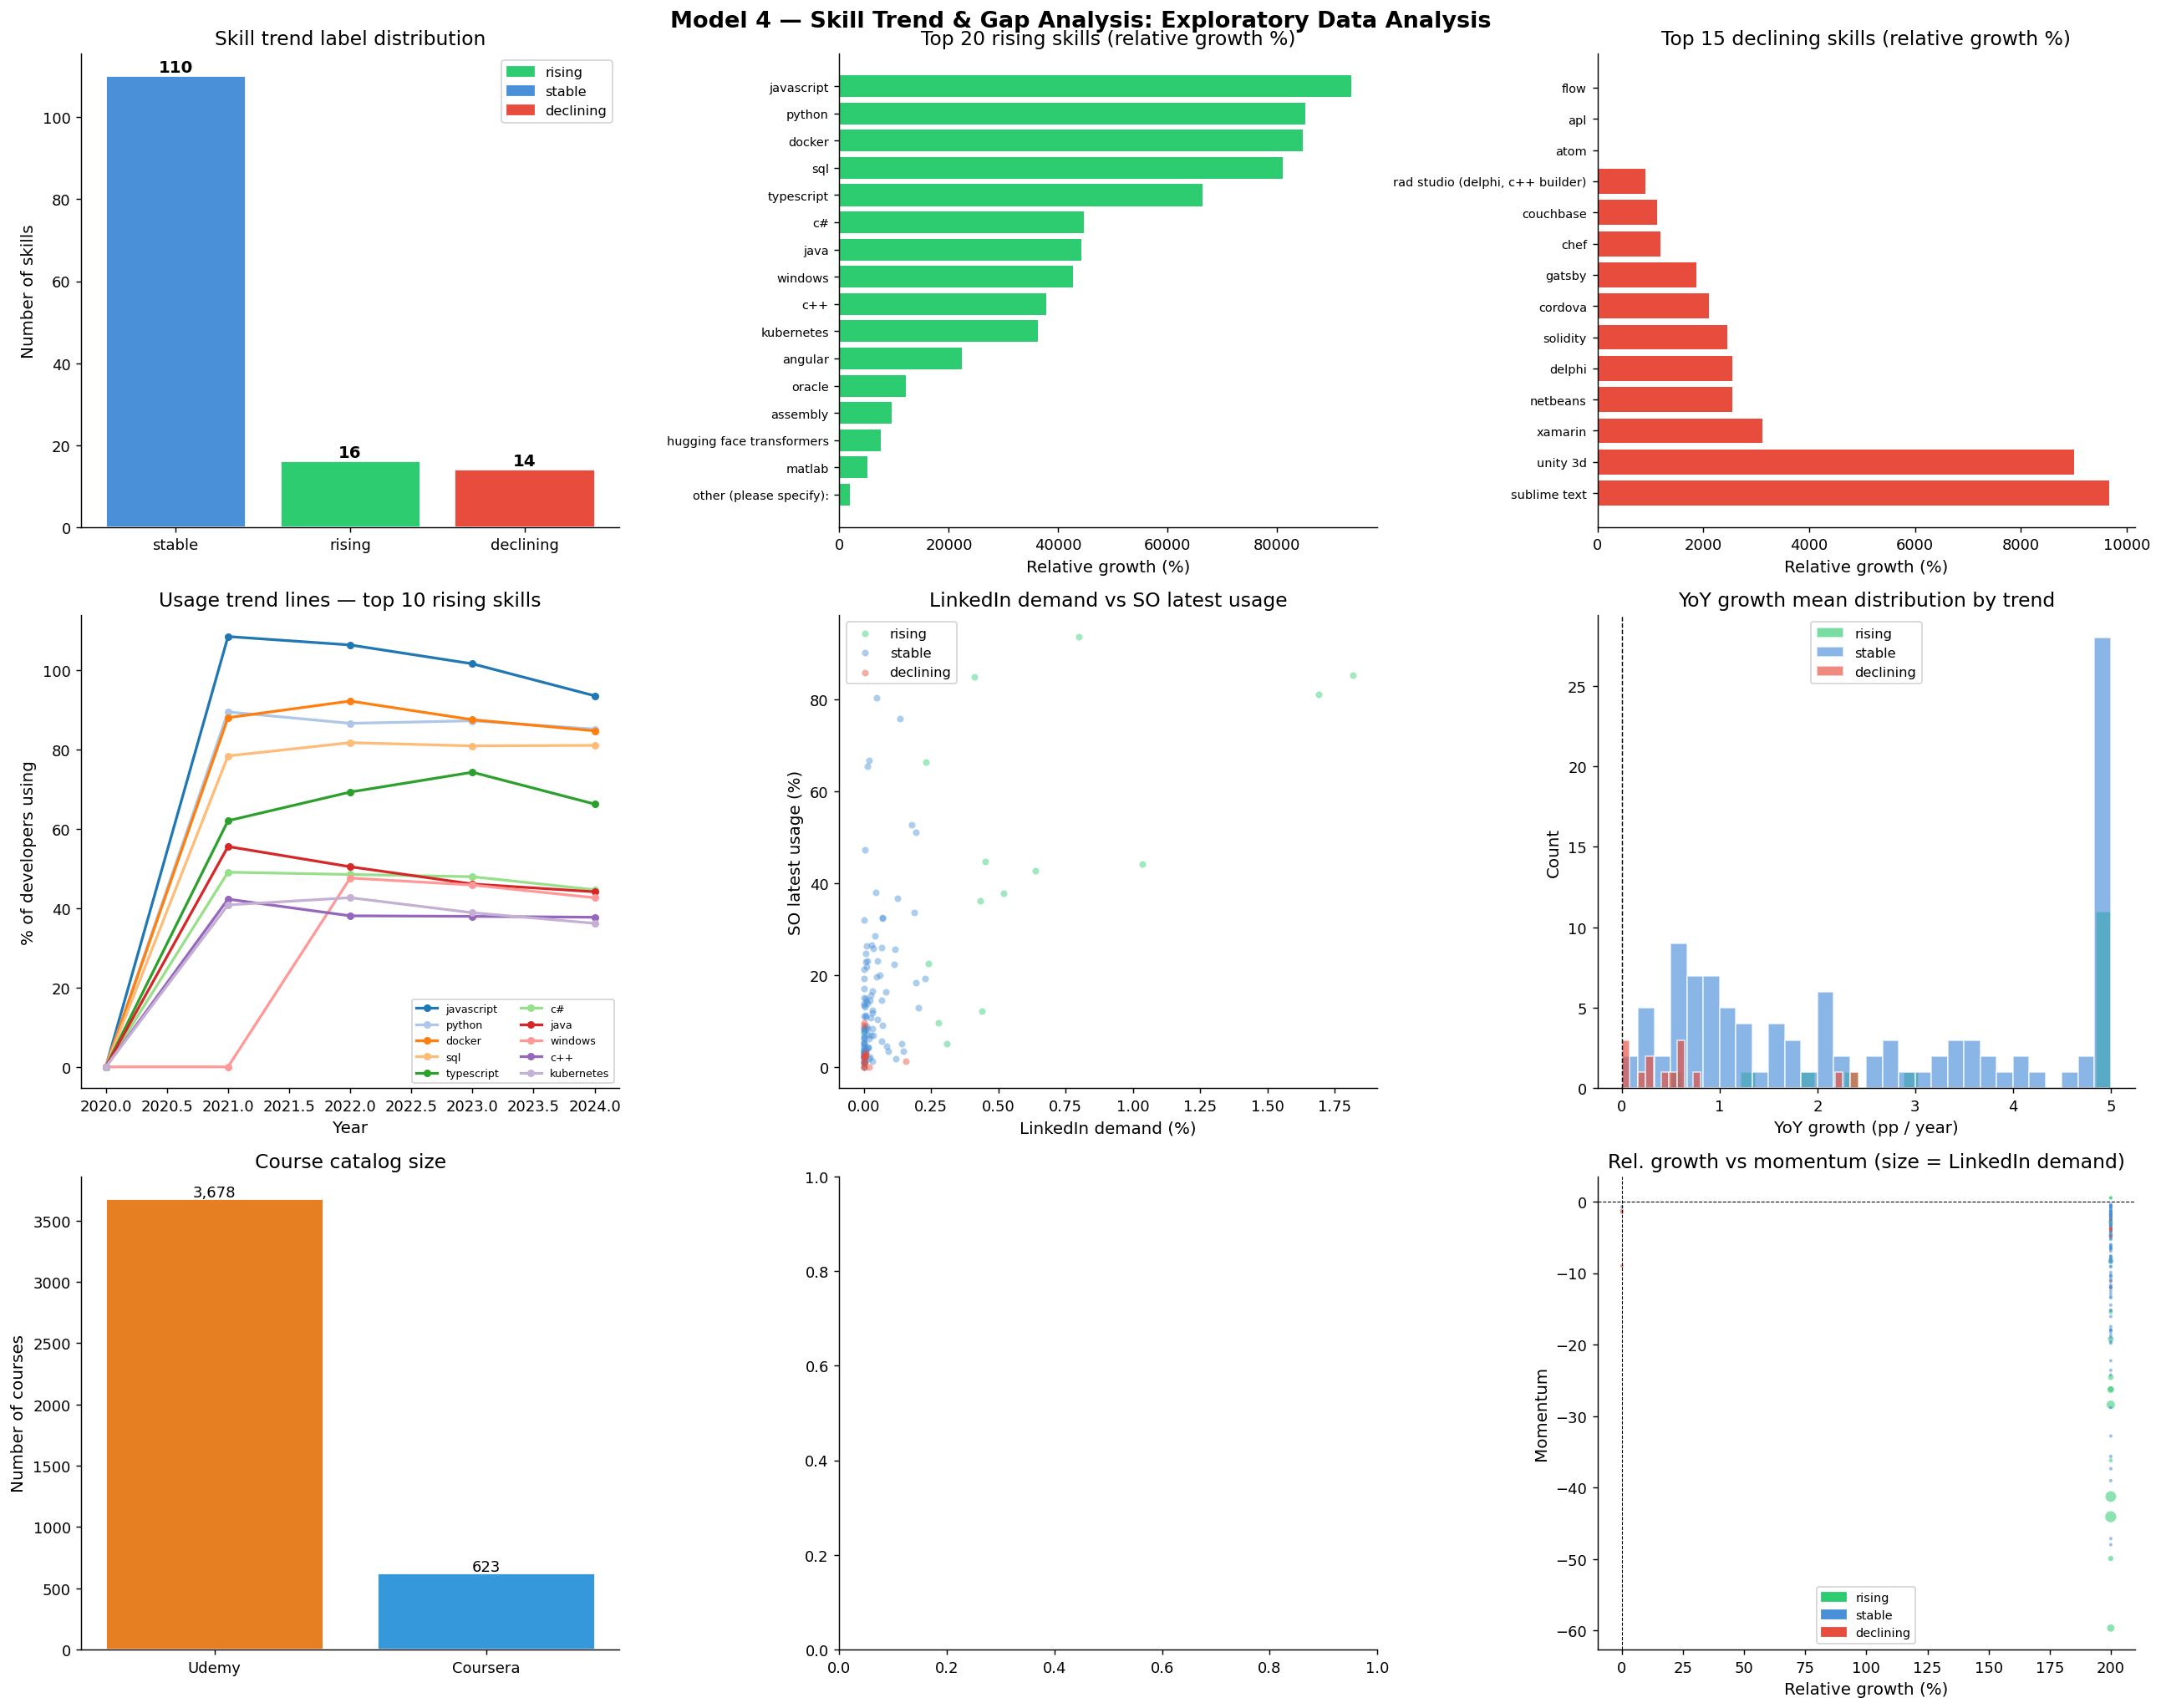

EDA plots saved.


In [8]:
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('Model 4 — Skill Trend & Gap Analysis: Exploratory Data Analysis',
             fontsize=15, fontweight='bold')

# ── 1. Trend label distribution ───────────────────────────────────────────────
ax = axes[0, 0]
colors_lbl = {'rising':'#2ECC71', 'stable':'#4A90D9', 'declining':'#E74C3C'}
ax.bar(label_dist.index, label_dist.values,
       color=[colors_lbl[l] for l in label_dist.index], edgecolor='white')
ax.set_title('Skill trend label distribution')
ax.set_ylabel('Number of skills')
for i, (l, v) in enumerate(zip(label_dist.index, label_dist.values)):
    ax.text(i, v + 1, str(v), ha='center', fontsize=11, fontweight='bold')
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in colors_lbl.items()]
ax.legend(handles=legend_patches, fontsize=9)

# ── 2. Top 20 rising skills ────────────────────────────────────────────────────
ax = axes[0, 1]
top_rising = (df_trends[df_trends['trend_label']=='rising']
              .nlargest(20, 'rel_growth'))
ax.barh(top_rising['skill'][::-1], top_rising['rel_growth'][::-1], color='#2ECC71')
ax.set_title('Top 20 rising skills (relative growth %)')
ax.set_xlabel('Relative growth (%)')
ax.tick_params(axis='y', labelsize=8)

# ── 3. Top 15 declining skills ────────────────────────────────────────────────
ax = axes[0, 2]
top_declining = (df_trends[df_trends['trend_label']=='declining']
                 .nsmallest(15, 'rel_growth'))
ax.barh(top_declining['skill'][::-1], top_declining['rel_growth'][::-1], color='#E74C3C')
ax.set_title('Top 15 declining skills (relative growth %)')
ax.set_xlabel('Relative growth (%)')
ax.tick_params(axis='y', labelsize=8)

# ── 4. Skill usage trend lines (top 10 rising) ────────────────────────────────
ax = axes[1, 0]
top10_rising = df_trends[df_trends['trend_label']=='rising'].nlargest(10, 'pct_latest')

for i, (_, row) in enumerate(top10_rising.iterrows()):
    skill_name = row['skill']

    # THE FIX: Look up the raw yearly data from df_so
    so_row = df_so[df_so['skill'] == skill_name].iloc[0]
    pcts = [so_row[f'pct_{yr}'] for yr in years if f'pct_{yr}' in so_row.index]

    ax.plot(years, pcts, 'o-', color=PALETTE[i], label=skill_name, linewidth=1.8, markersize=4)

ax.set_title('Usage trend lines — top 10 rising skills')
ax.set_xlabel('Year'); ax.set_ylabel('% of developers using')
ax.legend(fontsize=7, ncol=2)

# ── 5. LinkedIn demand vs SO trend ────────────────────────────────────────────
ax = axes[1, 1]
for lbl, color in colors_lbl.items():
    sub = df_trends[df_trends['trend_label'] == lbl]
    ax.scatter(sub['linkedin_demand'], sub['pct_latest'],
               alpha=0.45, s=20, color=color, label=lbl, linewidths=0)
ax.set_title('LinkedIn demand vs SO latest usage')
ax.set_xlabel('LinkedIn demand (%)'); ax.set_ylabel('SO latest usage (%)')
ax.legend(fontsize=9)

# ── 6. YoY growth distribution by trend label ─────────────────────────────────
ax = axes[1, 2]
for lbl, color in colors_lbl.items():
    sub = df_trends[df_trends['trend_label'] == lbl]['yoy_growth_mean']
    ax.hist(sub.clip(-5, 5), bins=30, alpha=0.65, color=color, label=lbl, edgecolor='white', lw=0.2)
ax.set_title('YoY growth mean distribution by trend')
ax.set_xlabel('YoY growth (pp / year)'); ax.set_ylabel('Count')
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.legend(fontsize=9)

# ── 7. Course platform distribution ──────────────────────────────────────────
ax = axes[2, 0]
udemy_sub  = min(500, len(df_udemy))
course_vc  = pd.Series({'Udemy': len(df_udemy), 'Coursera': len(df_coursera)})
ax.bar(course_vc.index, course_vc.values, color=['#E67E22','#3498DB'], edgecolor='white')
ax.set_title('Course catalog size')
ax.set_ylabel('Number of courses')
for i, (l, v) in enumerate(course_vc.items()):
    ax.text(i, v + 20, f'{v:,}', ha='center', fontsize=10)

# ── 8. Udemy course rating distribution ───────────────────────────────────────
ax = axes[2, 1]
rating_col = [c for c in df_udemy.columns if 'rating' in c.lower()]
if rating_col:
    ratings = df_udemy[rating_col[0]].dropna()
    ax.hist(ratings, bins=40, color='#E67E22', edgecolor='white', lw=0.3)
    ax.axvline(ratings.mean(), color='crimson', linestyle='--',
               label=f'Mean: {ratings.mean():.2f}')
    ax.set_title('Udemy course rating distribution')
    ax.set_xlabel('Rating'); ax.legend(fontsize=9)

# ── 9. Momentum vs Relative Growth scatter (bubble = LinkedIn demand) ─────────
ax = axes[2, 2]
sample_df = df_trends.sample(min(300, len(df_trends)), random_state=SEED)
color_map  = sample_df['trend_label'].map(colors_lbl)
sizes      = np.clip(sample_df['linkedin_demand'] * 30, 5, 200)
sc = ax.scatter(sample_df['rel_growth'].clip(-100, 200),
                sample_df['momentum'],
                c=color_map, s=sizes, alpha=0.55, linewidths=0)
ax.axhline(0, color='black', lw=0.6, linestyle='--')
ax.axvline(0, color='black', lw=0.6, linestyle='--')
ax.set_title('Rel. growth vs momentum (size = LinkedIn demand)')
ax.set_xlabel('Relative growth (%)'); ax.set_ylabel('Momentum')
ax.legend(handles=legend_patches, fontsize=8)

plt.tight_layout()
plt.savefig('eda_skill_gap_overview.png', bbox_inches='tight')
plt.show()
print('EDA plots saved.')

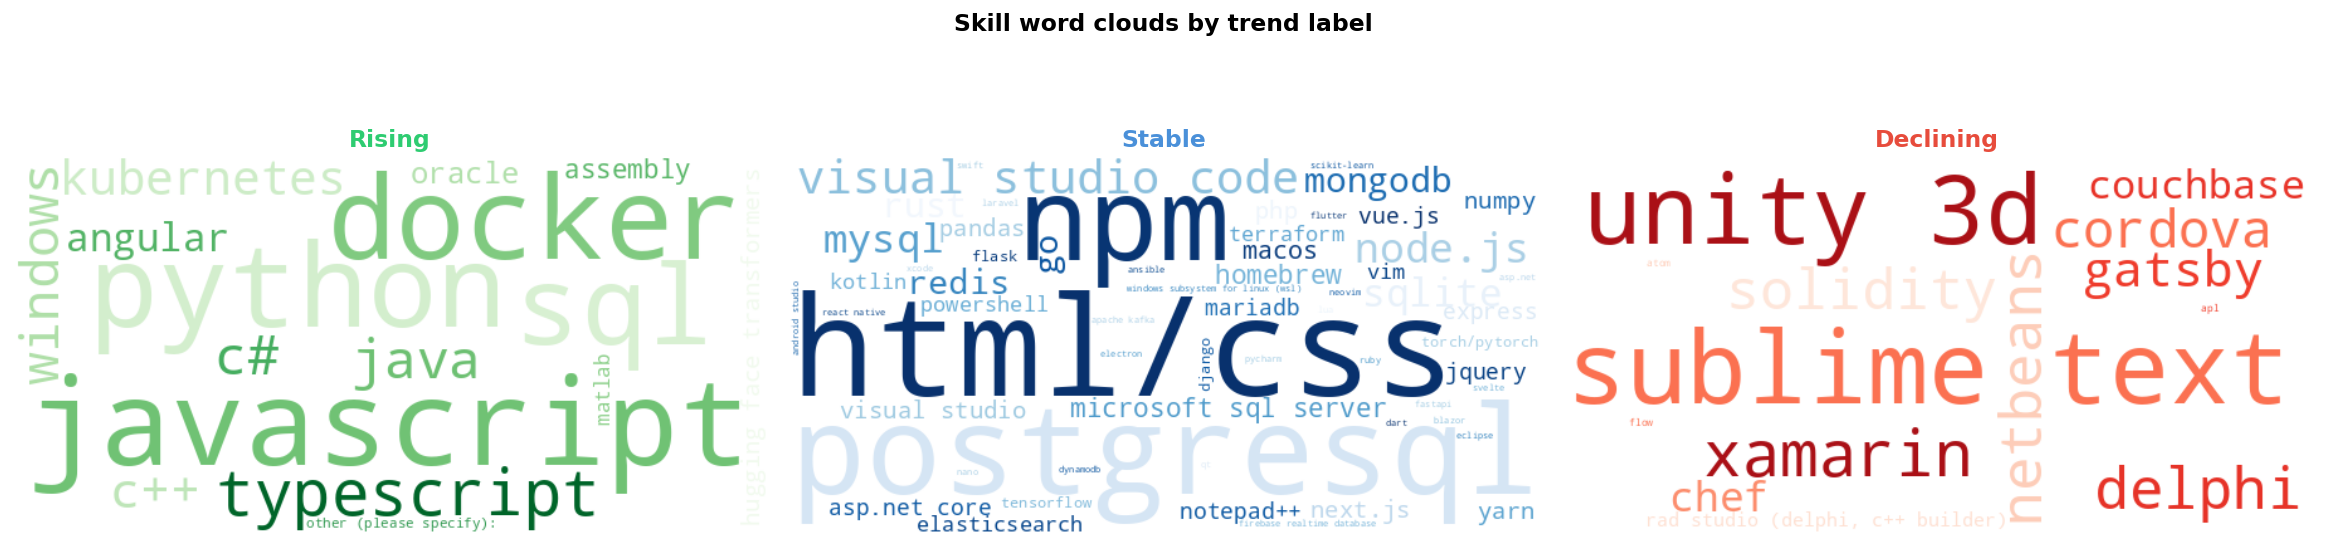

In [9]:
# ── Word clouds: Rising vs Declining skills ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Skill word clouds by trend label', fontsize=13, fontweight='bold')
for ax, lbl, cmap in [( axes[0], 'rising','Greens'),
                       ( axes[1], 'stable','Blues'),
                       ( axes[2], 'declining','Reds')]:
    sub = df_trends[df_trends['trend_label']==lbl]
    freq = dict(zip(sub['skill'], sub['pct_latest'].clip(lower=0.01)))
    if freq:
        wc = WordCloud(width=600, height=300, background_color='white',
                       colormap=cmap, max_words=60).generate_from_frequencies(freq)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(lbl.title(), fontweight='bold',
                 color=colors_lbl[lbl])
plt.tight_layout()
plt.savefig('wordclouds_trends.png', bbox_inches='tight')
plt.show()

## 🔢 Cell 7 — Normalisation & PCA on trend features

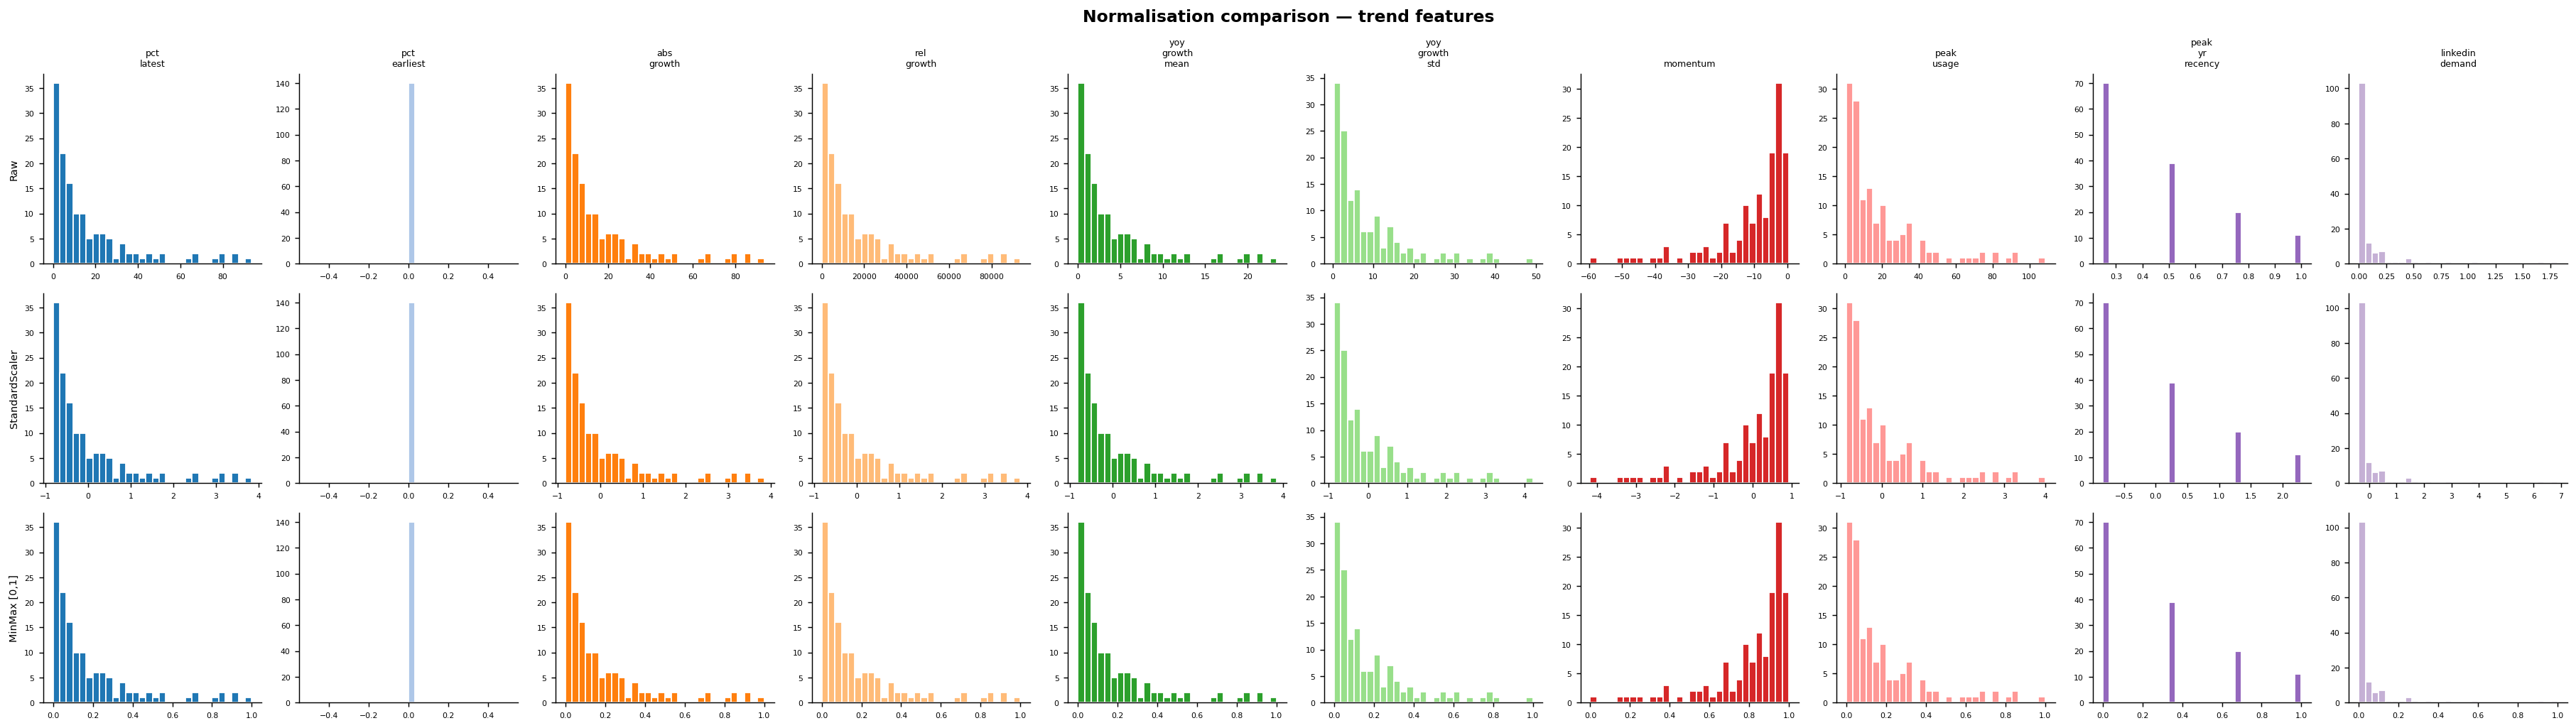

PCs for 95% variance: 3
Feature loadings on PC1:
  rel_growth             +0.368
  yoy_growth_mean        +0.368
  pct_latest             +0.368
  abs_growth             +0.368
  peak_usage             +0.368
  yoy_growth_std         +0.364
  momentum               -0.362
  linkedin_demand        +0.243
  peak_yr_recency        -0.012
  pct_earliest           +0.000


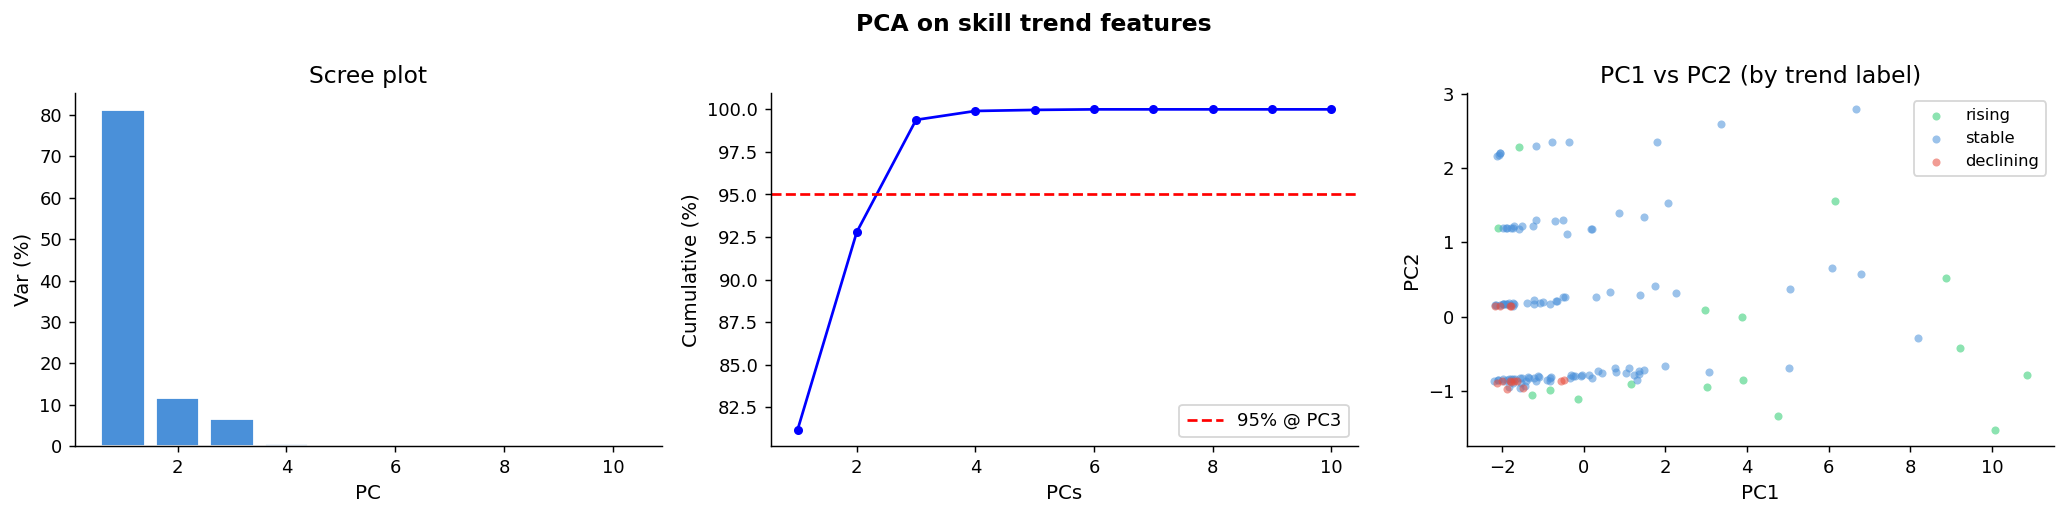

In [10]:
FEAT_COLS = ['pct_latest','pct_earliest','abs_growth','rel_growth',
             'yoy_growth_mean','yoy_growth_std','momentum',
             'peak_usage','peak_yr_recency','linkedin_demand']

X_raw = df_trends[FEAT_COLS].values.astype(float)
y_cls = df_trends['trend_id'].values.astype(int)

# ── Normalization comparison ──────────────────────────────────────────────────
scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()
X_std = scaler_std.fit_transform(X_raw)
X_mm  = scaler_mm.fit_transform(X_raw)

fig, axes = plt.subplots(3, len(FEAT_COLS), figsize=(28, 8))
fig.suptitle('Normalisation comparison — trend features', fontsize=13, fontweight='bold')
for ci, feat in enumerate(FEAT_COLS):
    for ri, (data, lbl) in enumerate([
        (X_raw[:, ci],  'Raw'),
        (X_std[:, ci],  'StandardScaler'),
        (X_mm[:, ci],   'MinMax [0,1]')
    ]):
        ax = axes[ri, ci]
        ax.hist(data, bins=30, color=PALETTE[ci % 20], edgecolor='white', lw=0.2)
        ax.set_title(feat.replace('_','\n') if ri==0 else '', fontsize=7)
        ax.set_ylabel(lbl if ci==0 else '', fontsize=8)
        ax.tick_params(labelsize=6)
plt.tight_layout()
plt.savefig('normalisation_trend_features.png', bbox_inches='tight')
plt.show()

# ── PCA ───────────────────────────────────────────────────────────────────────
pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(X_std)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n95 = int(np.searchsorted(cum_var, 0.95)) + 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('PCA on skill trend features', fontsize=13, fontweight='bold')

axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1),
            pca.explained_variance_ratio_*100, color='#4A90D9', edgecolor='white')
axes[0].set_title('Scree plot')
axes[0].set_xlabel('PC'); axes[0].set_ylabel('Var (%)')

axes[1].plot(range(1, len(cum_var)+1), cum_var*100, 'b-o', markersize=4)
axes[1].axhline(95, color='red', linestyle='--', label=f'95% @ PC{n95}')
axes[1].legend(); axes[1].set_xlabel('PCs'); axes[1].set_ylabel('Cumulative (%)')

label_colors = [colors_lbl[df_trends['trend_label'].iloc[i]] for i in range(len(X_pca))]
for lbl, color in colors_lbl.items():
    mask = [i for i, l in enumerate(df_trends['trend_label']) if l == lbl]
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], label=lbl, color=color,
                    alpha=0.55, s=20, linewidths=0)
axes[2].legend(fontsize=9); axes[2].set_title('PC1 vs PC2 (by trend label)')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

print(f'PCs for 95% variance: {n95}')
print('Feature loadings on PC1:')
for f, l in sorted(zip(FEAT_COLS, pca.components_[0]), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {f:<22} {l:+.3f}')
plt.tight_layout()
plt.savefig('pca_trend_features.png', bbox_inches='tight')
plt.show()

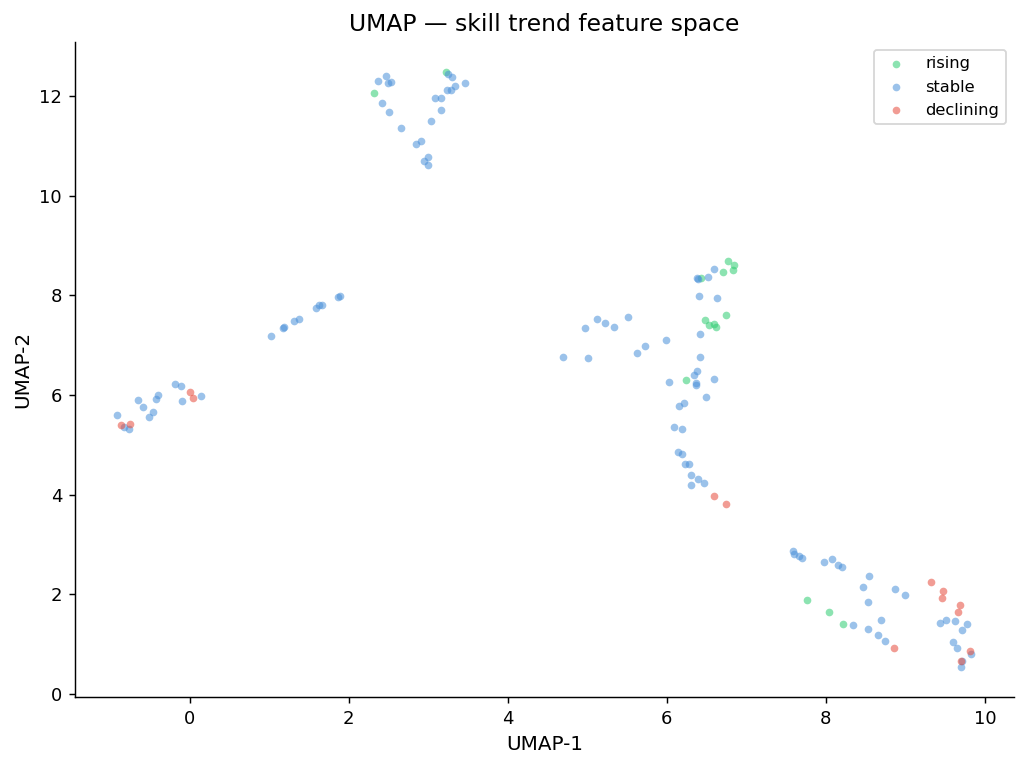

In [11]:
# ── UMAP ─────────────────────────────────────────────────────────────────────
try:
    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15,
                        min_dist=0.1, metric='euclidean')
    X_umap = reducer.fit_transform(X_std)
    fig, ax = plt.subplots(figsize=(8, 6))
    for lbl, color in colors_lbl.items():
        mask = df_trends['trend_label'] == lbl
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1], label=lbl, color=color,
                   alpha=0.55, s=18, linewidths=0)
    ax.legend(fontsize=9); ax.set_title('UMAP — skill trend feature space')
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    plt.tight_layout()
    plt.savefig('umap_trends.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'UMAP skipped: {e}')

## ✂️ Cell 8 — Train / Validation / Test split

Train  :   105 skills
Val    :    17 skills
Test   :    18 skills


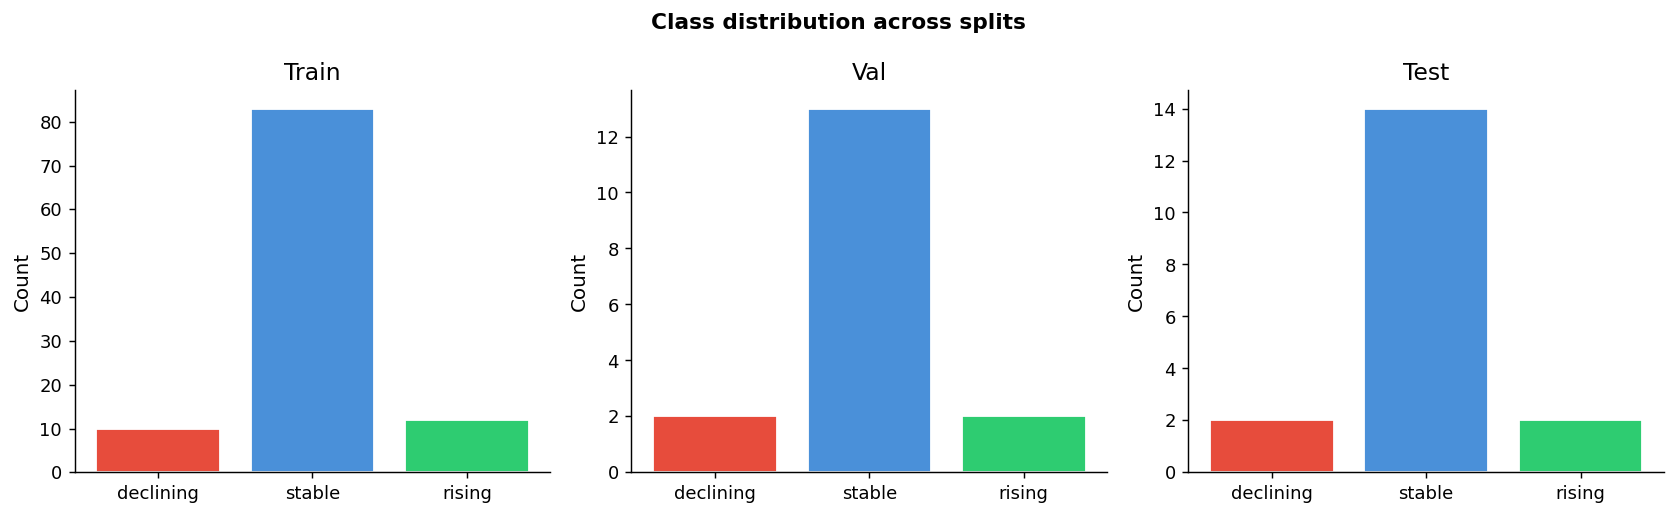

In [12]:
# Stratified split
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_raw, y_cls, test_size=0.25, random_state=SEED, stratify=y_cls
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=SEED, stratify=y_tmp
)

# Fit scaler on train only
scaler = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)
X_te_sc  = scaler.transform(X_test)

print(f'Train  : {len(X_tr):>5} skills')
print(f'Val    : {len(X_val):>5} skills')
print(f'Test   : {len(X_test):>5} skills')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Class distribution across splits', fontsize=12, fontweight='bold')
id2lbl = {v: k for k, v in TREND_MAP.items()}
split_colors = ['#4A90D9', '#2ECC71', '#E74C3C']
for ax, y, title in [(axes[0], y_tr, 'Train'), (axes[1], y_val, 'Val'), (axes[2], y_test, 'Test')]:
    vc = Counter(y)
    lbls = [id2lbl[k] for k in sorted(vc)]
    ax.bar(lbls, [vc[k] for k in sorted(vc)],
           color=[colors_lbl[l] for l in lbls], edgecolor='white')
    ax.set_title(title); ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('split_distribution.png', bbox_inches='tight')
plt.show()

## 🤖 Cell 9 — Trend Classifier (XGBoost multi-class)

In [13]:
# ── XGBoost multi-class classifier ────────────────────────────────────────────
xgb_cls = xgb.XGBClassifier(
    n_estimators          = 600,
    max_depth             = 5,
    learning_rate         = 0.05,
    subsample             = 0.80,
    colsample_bytree      = 0.80,
    min_child_weight      = 3,
    gamma                 = 0.1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    objective             = 'multi:softprob',
    num_class             = 3,
    eval_metric           = 'mlogloss',
    early_stopping_rounds = 40,
    random_state          = SEED,
    n_jobs                = -1,
    use_label_encoder     = False
)
xgb_cls.fit(X_tr_sc, y_tr, eval_set=[(X_val_sc, y_val)], verbose=100)

# ── LightGBM classifier ────────────────────────────────────────────────────────
lgb_cls = lgb.LGBMClassifier(
    n_estimators      = 600,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.80,
    colsample_bytree  = 0.80,
    min_child_samples = 5,
    num_class         = 3,
    objective         = 'multiclass',
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = SEED,
    n_jobs            = -1,
    verbose           = -1
)
lgb_cls.fit(X_tr_sc, y_tr,
            eval_set=[(X_val_sc, y_val)],
            callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(100)])

# ── Ensemble: soft-vote on class probabilities ─────────────────────────────────
def ensemble_predict(X_sc, w=0.55):
    prob_xgb = xgb_cls.predict_proba(X_sc)
    prob_lgb = lgb_cls.predict_proba(X_sc)
    return np.argmax(w * prob_xgb + (1-w) * prob_lgb, axis=1)

# Find best weight on validation
best_acc, best_w = 0, 0.5
for w in np.arange(0.1, 1.0, 0.05):
    preds = ensemble_predict(X_val_sc, w)
    acc   = accuracy_score(y_val, preds)
    if acc > best_acc: best_acc, best_w = acc, w
ENS_W = best_w
print(f'Best ensemble weight XGB: {ENS_W:.2f}, LGB: {1-ENS_W:.2f}')

# Evaluate on test set
y_pred_test = ensemble_predict(X_te_sc, ENS_W)
acc   = accuracy_score(y_test, y_pred_test)
f1    = f1_score(y_test, y_pred_test, average='macro')
print(f'\nTest Accuracy (ensemble): {acc:.4f}')
print(f'Test Macro F1 (ensemble): {f1:.4f}')
print('\nPer-class report:')
print(classification_report(y_test, y_pred_test,
                             target_names=['declining','stable','rising']))

[0]	validation_0-mlogloss:0.69556
[70]	validation_0-mlogloss:0.57808
Best ensemble weight XGB: 0.55, LGB: 0.45

Test Accuracy (ensemble): 0.9444
Test Macro F1 (ensemble): 0.8774

Per-class report:
              precision    recall  f1-score   support

   declining       1.00      0.50      0.67         2
      stable       0.93      1.00      0.97        14
      rising       1.00      1.00      1.00         2

    accuracy                           0.94        18
   macro avg       0.98      0.83      0.88        18
weighted avg       0.95      0.94      0.94        18



## ⚡ Cell 10 — Gap Priority Scorer (XGBoost regressor)

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Build a gap priority score (0-100) for each missing skill.
# Priority = how urgently a candidate SHOULD learn this skill.
#
# Priority features (5):
#   P1  demand_pct       — what % of target-role JDs require this skill
#   P2  trend_score      — 0=declining, 50=stable, 100=rising
#   P3  yoy_growth       — year-over-year growth momentum
#   P4  gap_severity     — 1 if completely missing, 0.5 if partially known
#   P5  job_freq_in_recs — how often this skill appears in Model 3's top-10 recs
#
# Priority label (pseudo):
#   priority = 0.35×demand + 0.30×trend + 0.20×yoy + 0.15×job_freq
#   (normalised to 0-100)
# ─────────────────────────────────────────────────────────────────────────────

# Build per-skill demand map from LinkedIn JDs (by role category)
li_jobs_df = pd.read_csv(LINKEDIN_JOBS_PATH, usecols=['job_link','job_title'], nrows=200_000, low_memory=False)
li_merged  = li_jobs_df.merge(df_li_skills, on='job_link', how='inner')

skill_col_li = [c for c in df_li_skills.columns if 'skill' in c.lower()][0]
title_col    = 'job_title'

# Build role → skill frequency table
role_skill_freq = defaultdict(Counter)
role_total      = Counter()

CAT_KW = {
    'Data Science'        : ['data scientist','machine learning','ml engineer','ai engineer'],
    'Software Engineering': ['software engineer','backend','frontend','developer','sde'],
    'Data Engineering'    : ['data engineer','etl','spark','databricks'],
    'Data Analytics'      : ['data analyst','business analyst','analytics'],
    'DevOps / Cloud'      : ['devops','cloud','sre','platform engineer'],
}

def infer_role(title):
    t = str(title).lower()
    for role, kws in CAT_KW.items():
        if any(kw in t for kw in kws): return role
    return 'Other'

for _, row in li_merged.iterrows():
    role = infer_role(row.get(title_col, ''))
    role_total[role] += 1
    skills_str = str(row.get(skill_col_li, ''))
    for sk in re.split(r'[;,|]', skills_str):
        t = sk.strip().lower()
        if t: role_skill_freq[role][t] += 1

# Normalise to demand %
role_skill_demand = {
    role: {sk: cnt/max(role_total[role],1)*100
           for sk, cnt in ctr.items()}
    for role, ctr in role_skill_freq.items()
}
print('Role-specific skill demand table built.')
print('Top skills for Data Science:')
ds_demand = sorted(role_skill_demand.get('Data Science',{}).items(), key=lambda x: -x[1])[:10]
print(ds_demand)

Role-specific skill demand table built.
Top skills for Data Science:
[('python', 84.0), ('machine learning', 76.0), ('sql', 44.0), ('pytorch', 40.0), ('tensorflow', 40.0), ('r', 36.0), ('data science', 32.0), ('data analysis', 28.000000000000004), ('hadoop', 28.000000000000004), ('aws', 24.0)]


In [15]:
# ── Build gap priority training dataset ────────────────────────────────────────
# For each skill in our trend DB, generate a priority score per role
trend_lookup = dict(zip(df_trends['skill'], df_trends['trend_label']))
trend_score_map = {'rising': 100, 'stable': 50, 'declining': 0}
yoy_lookup  = dict(zip(df_trends['skill'], df_trends['yoy_growth_mean']))

priority_rows = []
for role, skill_demand in role_skill_demand.items():
    if role == 'Other': continue
    for skill, demand_pct in skill_demand.items():
        if demand_pct < 1.0: continue   # skip very rare skills
        trend_lbl = trend_lookup.get(skill, 'stable')
        tr_score  = trend_score_map[trend_lbl]
        yoy       = float(np.clip(yoy_lookup.get(skill, 0.0), -5, 10))
        # job_freq: treat as demand_pct (proxy for how often it appears in recs)
        job_freq  = min(100, demand_pct * 1.2)
        # Pseudo priority
        priority  = (
            0.35 * min(demand_pct, 100) +
            0.30 * tr_score +
            0.20 * (yoy * 5 + 50) +   # map [-5,10] → [25,100]
            0.15 * job_freq
        )
        priority = float(np.clip(priority + np.random.normal(0, 1.5), 0, 100))
        priority_rows.append({
            'skill'       : skill,
            'role'        : role,
            'demand_pct'  : demand_pct,
            'trend_score' : tr_score,
            'yoy_growth'  : yoy,
            'gap_severity': 1.0,   # assume fully missing (adjusted at inference)
            'job_freq'    : job_freq,
            'priority'    : priority
        })

df_priority = pd.DataFrame(priority_rows)
PRIORITY_FEAT = ['demand_pct','trend_score','yoy_growth','gap_severity','job_freq']
print(f'Priority dataset shape : {df_priority.shape}')
print(df_priority['priority'].describe().round(2))

# ── Train / Val / Test split for priority regressor ───────────────────────────
Xp = df_priority[PRIORITY_FEAT].values
yp = df_priority['priority'].values
Xp_tr, Xp_tmp, yp_tr, yp_tmp = train_test_split(Xp, yp, test_size=0.25, random_state=SEED)
Xp_val, Xp_te, yp_val, yp_te = train_test_split(Xp_tmp, yp_tmp, test_size=0.5, random_state=SEED)

scaler_p = StandardScaler()
Xp_tr_sc = scaler_p.fit_transform(Xp_tr)
Xp_val_sc= scaler_p.transform(Xp_val)
Xp_te_sc = scaler_p.transform(Xp_te)

# ── Train XGBoost priority regressor ──────────────────────────────────────────
xgb_priority = xgb.XGBRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED,
    early_stopping_rounds=30, eval_metric='rmse', n_jobs=-1
)
xgb_priority.fit(Xp_tr_sc, yp_tr, eval_set=[(Xp_val_sc, yp_val)], verbose=50)

preds_te  = xgb_priority.predict(Xp_te_sc)
mae_p     = mean_absolute_error(yp_te, preds_te)
rmse_p    = np.sqrt(mean_squared_error(yp_te, preds_te))
sr_p, _   = spearmanr(yp_te, preds_te)
print(f'\nPriority regressor — Test MAE: {mae_p:.3f}  RMSE: {rmse_p:.3f}  Spearman ρ: {sr_p:.4f}')

Priority dataset shape : (3616, 8)
count    3616.00
mean       27.16
std         4.58
min         9.49
25%        25.24
50%        26.42
75%        27.80
max        93.61
Name: priority, dtype: float64
[0]	validation_0-rmse:3.59925
[50]	validation_0-rmse:1.54674
[100]	validation_0-rmse:1.53039
[105]	validation_0-rmse:1.53041

Priority regressor — Test MAE: 1.222  RMSE: 1.562  Spearman ρ: 0.5872


## 📚 Cell 11 — Course catalog preprocessing & TF-IDF matcher

In [16]:
# ── Udemy course preprocessing ────────────────────────────────────────────────
def normalise_udemy(df):
    # Detect column names flexibly
    title_c  = next((c for c in df.columns if 'title' in c.lower()), None)
    url_c    = next((c for c in df.columns if 'url' in c.lower() or 'link' in c.lower()), None)
    rating_c = next((c for c in df.columns if 'rating' in c.lower()), None)
    price_c  = next((c for c in df.columns if 'price' in c.lower()), None)
    enroll_c = next((c for c in df.columns if 'enroll' in c.lower() or 'subscriber' in c.lower()), None)
    subject_c= next((c for c in df.columns if 'subject' in c.lower() or 'topic' in c.lower() or 'category' in c.lower()), None)

    out = pd.DataFrame()
    out['title']      = df[title_c].astype(str).str.strip() if title_c else 'Unknown'
    out['url']        = df[url_c].astype(str) if url_c else ''
    out['rating']     = pd.to_numeric(df[rating_c], errors='coerce').fillna(3.5) if rating_c else 3.5
    out['is_free']    = False
    if price_c:
        price_series = df[price_c].astype(str).str.lower()
        out['is_free'] = price_series.isin(['0', '0.0', 'free'])
    out['enrollments']= pd.to_numeric(df[enroll_c], errors='coerce').fillna(0) if enroll_c else 0
    out['subject']    = df[subject_c].astype(str) if subject_c else ''
    out['platform']   = 'Udemy'
    out['text']       = out['title'] + ' ' + out['subject']
    return out.dropna(subset=['title'])

def normalise_coursera(df):
    title_c   = next((c for c in df.columns if 'title' in c.lower() or 'name' in c.lower()), None)
    url_c     = next((c for c in df.columns if 'url' in c.lower() or 'link' in c.lower()), None)
    rating_c  = next((c for c in df.columns if 'rating' in c.lower()), None)
    skills_c  = next((c for c in df.columns if 'skill' in c.lower()), None)
    partner_c = next((c for c in df.columns if 'partner' in c.lower() or 'org' in c.lower() or 'institution' in c.lower()), None)

    out = pd.DataFrame()
    out['title']      = df[title_c].astype(str).str.strip() if title_c else 'Unknown'
    out['url']        = df[url_c].astype(str) if url_c else ''
    out['rating']     = pd.to_numeric(df[rating_c], errors='coerce').fillna(4.0) if rating_c else 4.0
    out['is_free']    = True     # Coursera audit = free
    out['enrollments']= 0
    out['subject']    = df[skills_c].astype(str) if skills_c else ''
    out['partner']    = df[partner_c].astype(str) if partner_c else ''
    out['platform']   = 'Coursera'
    out['text']       = out['title'] + ' ' + out['subject'] + ' ' + out['partner']
    return out.dropna(subset=['title'])

df_udemy_clean    = normalise_udemy(df_udemy)
df_coursera_clean = normalise_coursera(df_coursera)
df_courses = pd.concat([df_udemy_clean, df_coursera_clean], ignore_index=True)
df_courses['text_clean'] = df_courses['text'].str.lower().str.replace(r'[^\w\s]', ' ', regex=True)

print(f'Total courses in catalog: {len(df_courses):,}')
print(f'  Udemy    : {len(df_udemy_clean):,}')
print(f'  Coursera : {len(df_coursera_clean):,}')
print(df_courses[['title','platform','rating','is_free']].head(5))

Total courses in catalog: 4,301
  Udemy    : 3,678
  Coursera : 623
                                               title platform  rating  is_free
0                 Ultimate Investment Banking Course    Udemy     3.5    False
1  Complete GST Course & Certification - Grow You...    Udemy     3.5    False
2  Financial Modeling for Business Analysts and C...    Udemy     3.5    False
3  Beginner to Pro - Financial Analysis in Excel ...    Udemy     3.5    False
4       How To Maximize Your Profits Trading Options    Udemy     3.5    False


In [17]:
# ── TF-IDF course matcher ─────────────────────────────────────────────────────
print('Fitting TF-IDF on course catalog...')
tfidf_courses = TfidfVectorizer(
    max_features = 6000,
    ngram_range  = (1, 2),
    stop_words   = 'english',
    min_df       = 1,
    sublinear_tf = True
)
course_tfidf_matrix = tfidf_courses.fit_transform(df_courses['text_clean'])
print(f'TF-IDF matrix shape: {course_tfidf_matrix.shape}')

def find_courses_for_skill(skill: str, top_k: int = 5) -> list:
    """
    Return top_k most relevant courses for a given skill.
    Returns list of dicts sorted by relevance × rating score.
    """
    query_vec = tfidf_courses.transform([skill.lower()])
    sims      = cosine_similarity(query_vec, course_tfidf_matrix)[0]
    top_idx   = np.argsort(sims)[::-1][:top_k * 3]  # over-fetch, then re-rank by rating

    candidates = []
    for idx in top_idx:
        if sims[idx] < 0.01: continue
        row = df_courses.iloc[idx]
        # Combined score: 60% relevance + 40% normalised rating
        combined = 0.60 * sims[idx] + 0.40 * (row['rating'] / 5.0)
        candidates.append({
            'title'      : row['title'],
            'platform'   : row['platform'],
            'is_free'    : bool(row['is_free']),
            'rating'     : round(float(row['rating']), 1),
            'url'        : row['url'],
            'relevance'  : round(float(sims[idx]), 4),
            '_combined'  : combined
        })
    # Sort by combined score, then split free vs paid for diversity
    candidates.sort(key=lambda x: -x['_combined'])
    free_courses = [c for c in candidates if c['is_free']][:2]
    paid_courses = [c for c in candidates if not c['is_free']][:3]
    results = (free_courses + paid_courses)[:top_k]
    for c in results: c.pop('_combined', None)
    return results

# Quick test
test_courses = find_courses_for_skill('docker')
print(f'Courses found for "docker": {len(test_courses)}')
for c in test_courses:
    print(f"  [{c['platform']}] {c['title'][:60]}  ★{c['rating']}  Free:{c['is_free']}")

Fitting TF-IDF on course catalog...
TF-IDF matrix shape: (4301, 6000)
Courses found for "docker": 5
  [Udemy] Dive Into Docker: The Docker Course for Developers  ★3.5  Free:True
  [Coursera] 502  ★4.4  Free:True
  [Udemy] Learning Docker and Kubernetes by Lab  ★3.5  Free:False
  [Udemy] The Docker for DevOps course: From development to production  ★3.5  Free:False
  [Udemy] Scaling Docker on AWS  ★3.5  Free:False


## 🗺️ Cell 12 — Skill dependency graph & roadmap generator

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Skill prerequisite graph:
# Directed edges A → B mean "learn A before B"
# Built from domain knowledge. Extend as needed.
# ─────────────────────────────────────────────────────────────────────────────

SKILL_PREREQS = {
    # Programming fundamentals
    'python'          : [],
    'r'               : [],
    'sql'             : [],
    'java'            : [],
    'javascript'      : [],
    'typescript'      : ['javascript'],
    'scala'           : ['java'],
    'go'              : [],
    'rust'            : [],

    # Data science & ML
    'numpy'           : ['python'],
    'pandas'          : ['python', 'numpy'],
    'matplotlib'      : ['python', 'numpy'],
    'scikit-learn'    : ['python', 'numpy', 'pandas'],
    'statistics'      : ['python'],
    'machine learning': ['python', 'numpy', 'scikit-learn', 'statistics'],
    'deep learning'   : ['machine learning', 'numpy'],
    'tensorflow'      : ['python', 'deep learning'],
    'pytorch'         : ['python', 'deep learning'],
    'keras'           : ['tensorflow'],
    'nlp'             : ['python', 'machine learning'],
    'transformers'    : ['nlp', 'deep learning'],
    'huggingface'     : ['transformers'],
    'langchain'       : ['python', 'llm'],
    'llm'             : ['deep learning', 'nlp', 'transformers'],
    'computer vision' : ['deep learning', 'numpy'],
    'mlflow'          : ['machine learning'],
    'kubeflow'        : ['machine learning', 'kubernetes'],

    # Data engineering
    'spark'           : ['python', 'sql'],
    'hadoop'          : ['java'],
    'kafka'           : ['python'],
    'airflow'         : ['python'],
    'dbt'             : ['sql'],
    'databricks'      : ['spark', 'sql'],
    'snowflake'       : ['sql'],
    'elasticsearch'   : ['python'],

    # Cloud & DevOps
    'linux'           : [],
    'git'             : [],
    'docker'          : ['linux'],
    'kubernetes'      : ['docker'],
    'terraform'       : ['cloud computing'],
    'ansible'         : ['linux'],
    'aws'             : ['linux', 'cloud computing'],
    'azure'           : ['linux', 'cloud computing'],
    'gcp'             : ['linux', 'cloud computing'],
    'cloud computing' : ['linux'],
    'ci/cd'           : ['git', 'docker'],

    # Web
    'react'           : ['javascript'],
    'angular'         : ['typescript'],
    'node.js'         : ['javascript'],
    'django'          : ['python'],
    'flask'           : ['python'],
    'fastapi'         : ['python'],
    'rest api'        : ['http basics'],
    'graphql'         : ['rest api'],
    'http basics'     : [],

    # Analytics
    'power bi'        : ['sql'],
    'tableau'         : ['sql'],
    'excel'           : [],
}

# Estimated weeks to learn each skill (assuming ~2h/day)
LEARN_WEEKS = {
    'python':3,'r':3,'sql':2,'java':6,'javascript':4,'typescript':2,'scala':5,
    'go':4,'rust':6,'numpy':1,'pandas':1,'matplotlib':1,'scikit-learn':2,
    'statistics':3,'machine learning':6,'deep learning':8,'tensorflow':4,
    'pytorch':4,'keras':2,'nlp':5,'transformers':4,'huggingface':2,'langchain':2,
    'llm':6,'computer vision':5,'mlflow':1,'kubeflow':2,'spark':4,'hadoop':3,
    'kafka':2,'airflow':2,'dbt':2,'databricks':2,'snowflake':2,'elasticsearch':2,
    'linux':2,'git':1,'docker':2,'kubernetes':4,'terraform':3,'ansible':2,
    'aws':6,'azure':6,'gcp':6,'cloud computing':3,'ci/cd':2,'react':5,
    'angular':5,'node.js':4,'django':3,'flask':2,'fastapi':2,'rest api':2,
    'graphql':2,'http basics':1,'power bi':2,'tableau':2,'excel':1,
}
DEFAULT_WEEKS = 2

G = nx.DiGraph()
for skill, prereqs in SKILL_PREREQS.items():
    G.add_node(skill)
    for p in prereqs:
        G.add_edge(p, skill)
print(f'Skill graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

def get_learning_order(gap_skills: list, resume_skills: list) -> list:
    """Topological sort on subgraph of gap skills, respecting prerequisites."""
    resume_set = set(s.lower() for s in resume_skills)
    subgraph_nodes = set()
    for sk in gap_skills:
        sk = sk.lower()
        subgraph_nodes.add(sk)
        # Add missing prerequisites
        for prereq in SKILL_PREREQS.get(sk, []):
            if prereq not in resume_set:
                subgraph_nodes.add(prereq)

    sub_g = G.subgraph(subgraph_nodes).copy()
    # Add edges for any nodes in subgraph not in full graph
    for sk in list(subgraph_nodes):
        if sk not in G:
            sub_g.add_node(sk)

    try:
        ordered = list(nx.topological_sort(sub_g))
    except nx.NetworkXUnfeasible:
        ordered = list(subgraph_nodes)   # fallback if cycle detected

    # Only return skills that are actual gaps (not already in resume)
    return [sk for sk in ordered if sk not in resume_set]

print('Skill dependency graph built.')

Skill graph: 58 nodes, 70 edges
Skill dependency graph built.


## 📊 Cell 13 — Model performance visualisations + SHAP

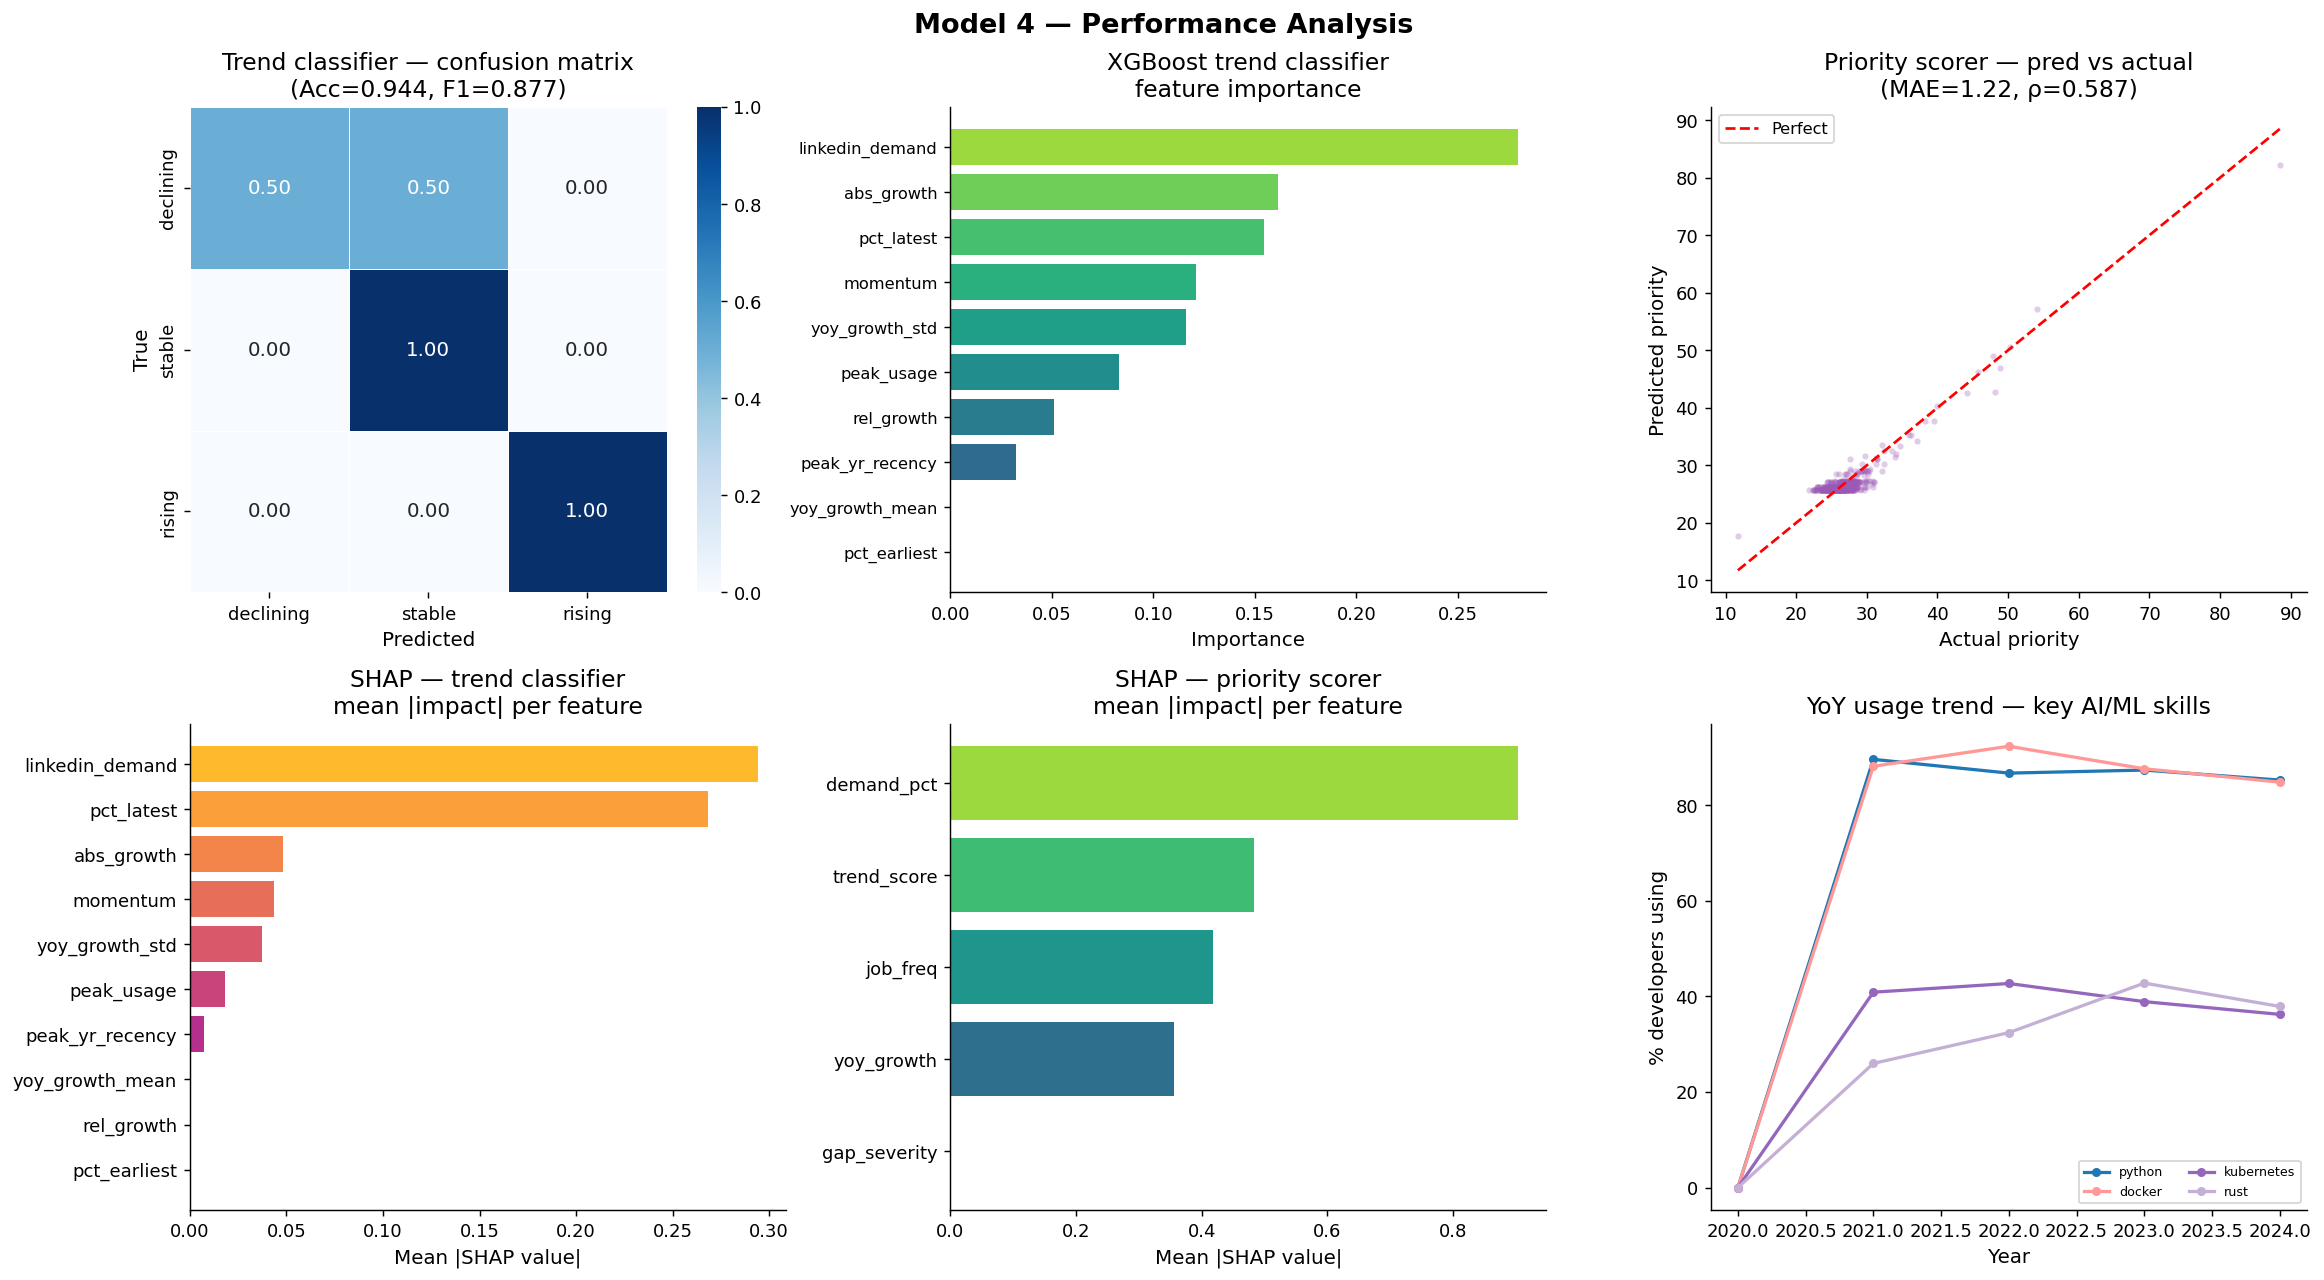

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model 4 — Performance Analysis', fontsize=15, fontweight='bold')

# ── 1. Trend classifier confusion matrix ─────────────────────────────────────
ax = axes[0, 0]
cm_arr = confusion_matrix(y_test, y_pred_test, normalize='true')
sns.heatmap(cm_arr, ax=ax, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['declining','stable','rising'],
            yticklabels=['declining','stable','rising'],
            linewidths=0.5, annot_kws={'size': 11})
ax.set_title(f'Trend classifier — confusion matrix\n(Acc={acc:.3f}, F1={f1:.3f})')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

# ── 2. Trend classifier feature importance ─────────────────────────────────────
ax = axes[0, 1]
fi = dict(zip(FEAT_COLS, xgb_cls.feature_importances_))
fi_s = dict(sorted(fi.items(), key=lambda x: x[1]))
ax.barh(list(fi_s.keys()), list(fi_s.values()),
        color=plt.cm.viridis(np.linspace(0.2, 0.85, len(fi_s))))
ax.set_title('XGBoost trend classifier\nfeature importance')
ax.set_xlabel('Importance')
ax.tick_params(axis='y', labelsize=9)

# ── 3. Priority regressor: predicted vs actual ────────────────────────────────
ax = axes[0, 2]
ax.scatter(yp_te, preds_te, alpha=0.3, s=12, color='#9B59B6', linewidths=0)
mn, mx = min(yp_te.min(), preds_te.min()), max(yp_te.max(), preds_te.max())
ax.plot([mn,mx],[mn,mx],'r--',lw=1.5, label='Perfect')
ax.set_title(f'Priority scorer — pred vs actual\n(MAE={mae_p:.2f}, ρ={sr_p:.3f})')
ax.set_xlabel('Actual priority'); ax.set_ylabel('Predicted priority')
ax.legend(fontsize=9)

# ── 4. SHAP — trend classifier ────────────────────────────────────────────────
ax = axes[1, 0]
explainer_cls = shap.TreeExplainer(xgb_cls)
shap_cls = explainer_cls.shap_values(X_te_sc[:200])

# Handle SHAP multi-class format changes across library versions
if isinstance(shap_cls, list):
    shap_mean = np.mean([np.abs(s) for s in shap_cls], axis=0).mean(axis=0)
elif len(shap_cls.shape) == 3:
    # Shape is (samples, features, classes) -> Mean across samples, then mean across classes
    shap_mean = np.abs(shap_cls).mean(axis=0).mean(axis=1)
else:
    shap_mean = np.abs(shap_cls).mean(axis=0)

shap_df = pd.Series(dict(zip(FEAT_COLS, shap_mean))).sort_values()
ax.barh(shap_df.index, shap_df.values,
        color=plt.cm.plasma(np.linspace(0.2, 0.85, len(shap_df))))
ax.set_title('SHAP — trend classifier\nmean |impact| per feature')
ax.set_xlabel('Mean |SHAP value|')

# ── 5. SHAP — priority regressor ─────────────────────────────────────────────
ax = axes[1, 1]
explainer_p  = shap.TreeExplainer(xgb_priority)
shap_p_vals  = explainer_p.shap_values(Xp_te_sc[:200])
shap_p_mean  = np.abs(shap_p_vals).mean(axis=0)
shap_p_df    = pd.Series(dict(zip(PRIORITY_FEAT, shap_p_mean))).sort_values()
ax.barh(shap_p_df.index, shap_p_df.values,
        color=plt.cm.viridis(np.linspace(0.2, 0.85, len(shap_p_df))))
ax.set_title('SHAP — priority scorer\nmean |impact| per feature')
ax.set_xlabel('Mean |SHAP value|')

# ── 6. Year-over-year trend for top rising AI skills ─────────────────────────
ax = axes[1, 2]
ai_skills = ['python','machine learning','deep learning','llm','transformers',
             'langchain','huggingface','docker','kubernetes','rust']
for i, sk in enumerate(ai_skills):
    row = df_so[df_so['skill'] == sk]
    if row.empty: continue
    row = row.iloc[0]
    pcts = [row.get(f'pct_{yr}', 0) for yr in years]
    if max(pcts) < 0.1: continue
    ax.plot(years, pcts, 'o-', label=sk, linewidth=1.8,
            markersize=4, color=PALETTE[i % 20])
ax.set_title('YoY usage trend — key AI/ML skills')
ax.set_xlabel('Year'); ax.set_ylabel('% developers using')
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('model4_performance.png', bbox_inches='tight')
plt.show()

## 🔍 Cell 14 — Full inference pipeline (M1 + M2 + M3 → skill gap report)

In [22]:
def analyze_skill_gap(
    model1_output : dict,
    model2_output : dict,
    model3_output : dict,
    target_role   : str = None,
    top_k_gaps    : int = 10
) -> dict:
    """
    Full Model 4 inference.

    Parameters
    ----------
    model1_output : dict  — parse_resume() output from resume_parser.py
    model2_output : dict  — score_resume() output from resume_scorer.py
    model3_output : dict  — recommend_jobs() output from job_recommender.py
    target_role   : str   — override role; inferred from Model 3 if None
    top_k_gaps    : int   — max skill gaps to return in report
    """
    # ── Step 1: Extract current skills from Model 1 ────────────────────────────
    current_skills = set(s.lower().strip()
                         for s in model1_output.get('skills', []) if s.strip())
    years_exp  = model1_output.get('years_experience', 0)
    certs      = [c.lower() for c in model1_output.get('certifications', [])]

    # ── Step 2: Infer target role from Model 3 recommendations ─────────────────
    recs = model3_output.get('recommendations', [])
    if not target_role:
        if recs:
            cats = [r.get('category','') for r in recs[:5]]
            target_role = Counter(cats).most_common(1)[0][0]
        else:
            target_role = 'Data Science'

    # ── Step 3: Aggregate all skill gaps from upstream models ──────────────────
    gap_skill_counts = Counter()

    # From Model 2: missing_keywords
    for sk in model2_output.get('missing_keywords', []):
        gap_skill_counts[sk.lower()] += 3   # high weight — ATS confirmed gap

    # From Model 3: skill_gaps per recommendation
    for rec in recs[:10]:
        for sk in rec.get('skill_gaps', []):
            gap_skill_counts[sk.lower()] += 2

    # From role demand: skills demanded in target role but missing in resume
    role_demand = role_skill_demand.get(target_role,
                  role_skill_demand.get('Data Science', {}))
    for sk, demand in role_demand.items():
        if sk not in current_skills and demand > 5.0:
            gap_skill_counts[sk] += max(1, int(demand // 10))

    # Remove skills the candidate already has
    for sk in list(gap_skill_counts):
        if sk in current_skills:
            del gap_skill_counts[sk]

    # ── Step 4: Score each gap skill's priority ────────────────────────────────
    scored_gaps = []
    for sk, freq in gap_skill_counts.most_common(top_k_gaps * 2):
        demand_pct = role_demand.get(sk, 0.0)
        trend_row  = df_trends[df_trends['skill'] == sk]
        if not trend_row.empty:
            trend_lbl  = trend_row.iloc[0]['trend_label']
            yoy_growth = float(trend_row.iloc[0]['yoy_growth_mean'])
        else:
            # Classify using XGBoost if not in training data
            li_d = li_demand.get(sk, 0.0)
            feat_fallback = np.array([[li_d, 0, 0, 0, 0, 0, 0, li_d, 0.5, li_d]])
            feat_sc       = scaler.transform(feat_fallback)
            pred_id       = int(ensemble_predict(feat_sc, ENS_W)[0])
            trend_lbl     = id2lbl[pred_id]
            yoy_growth    = 0.0

        trend_sc = trend_score_map[trend_lbl]
        job_freq = min(100, demand_pct * 1.2)

        P_feat = np.array([[demand_pct, trend_sc,
                             np.clip(yoy_growth, -5, 10),
                             1.0,   # gap_severity = fully missing
                             job_freq]])
        P_sc   = scaler_p.transform(P_feat)
        priority = float(np.clip(xgb_priority.predict(P_sc)[0], 0, 100))

        # Urgency bucket
        if priority >= 75:   urgency = 'critical'
        elif priority >= 55: urgency = 'high'
        elif priority >= 35: urgency = 'medium'
        else:                urgency = 'low'

        # Find matching courses
        courses = find_courses_for_skill(sk, top_k=4)

        scored_gaps.append({
            'skill'         : sk,
            'urgency'       : urgency,
            'trend'         : trend_lbl,
            'demand_pct'    : round(demand_pct, 1),
            'yoy_growth_pct': round(yoy_growth, 2),
            'priority_score': round(priority, 1),
            'learning_weeks': LEARN_WEEKS.get(sk, DEFAULT_WEEKS),
            'courses'       : courses,
        })

    # Sort by priority descending
    scored_gaps.sort(key=lambda x: -x['priority_score'])
    scored_gaps = scored_gaps[:top_k_gaps]

    # ── Step 5: Rising skills to watch (not gaps, but future-proof) ───────────
    rising_skills = (
        df_trends[df_trends['trend_label'] == 'rising']
        .nlargest(20, 'rel_growth')['skill'].tolist()
    )
    watch_list = [sk for sk in rising_skills
                  if sk not in current_skills][:8]

    # Declining skills the candidate has (may deprioritise)
    declining = (
        df_trends[df_trends['trend_label'] == 'declining']['skill'].tolist()
    )
    stale_skills = [sk for sk in declining if sk in current_skills][:5]

    # ── Step 6: Build learning roadmap ────────────────────────────────────────
    gap_skill_names = [g['skill'] for g in scored_gaps]
    ordered_skills  = get_learning_order(gap_skill_names, list(current_skills))

    # Group ordered skills into phases
    roadmap   = []
    week_cur  = 1
    for phase_idx, sk in enumerate(ordered_skills[:12], 1):
        weeks_needed = LEARN_WEEKS.get(sk, DEFAULT_WEEKS)
        # Find best course for this skill
        sk_courses = find_courses_for_skill(sk, top_k=1)
        best_course = sk_courses[0]['title'] if sk_courses else f'Search "{sk} tutorial" online'
        roadmap.append({
            'phase'    : phase_idx,
            'weeks'    : f'{week_cur}–{week_cur + weeks_needed - 1}',
            'skill'    : sk,
            'milestone': f'Complete {sk} fundamentals and build a project using it',
            'resource' : best_course,
            'urgency'  : next((g['urgency'] for g in scored_gaps if g['skill']==sk), 'medium')
        })
        week_cur += weeks_needed

    total_weeks = week_cur - 1

    # ── Step 7: Overall gap score ──────────────────────────────────────────────
    # Weighted average of priority scores (higher = bigger gap)
    if scored_gaps:
        overall_gap = np.mean([g['priority_score'] for g in scored_gaps])
    else:
        overall_gap = 0.0

    return {
        'target_role'            : target_role,
        'current_skills'         : list(current_skills),
        'overall_gap_score'      : round(float(overall_gap), 1),
        'estimated_upskill_weeks': total_weeks,
        'skill_gaps'             : scored_gaps,
        'rising_skills_to_watch' : watch_list,
        'stale_skills_in_resume' : stale_skills,
        'roadmap'                : roadmap,
        '_meta': {
            'model'             : 'skill-gap-analyzer-v1',
            'n_gaps_found'      : len(scored_gaps),
            'n_role_jds_used'   : role_total.get(target_role, 0),
        }
    }

In [23]:
# ── DEMO — run full pipeline with all three upstream models' outputs ───────────

DEMO_M1 = {
    'name'            : 'Priya Mehta',
    'skills'          : ['python', 'machine learning', 'scikit-learn', 'sql',
                         'pandas', 'numpy', 'matplotlib', 'git', 'excel'],
    'designations'    : ['Data Analyst', 'Junior Data Scientist'],
    'companies'       : ['Wipro'],
    'degree'          : ['B.Tech Computer Science'],
    'certifications'  : ['Google Data Analytics Certificate'],
    'years_experience': 2,
    'location'        : ['Hyderabad, India'],
}

DEMO_M2 = {
    'ats_score'       : 62.3,
    'section_scores'  : {'skills': 55.0, 'experience': 70.0, 'education': 80.0},
    'missing_keywords': ['docker', 'kubernetes', 'spark', 'tensorflow', 'deep learning',
                         'mlflow', 'aws', 'airflow', 'power bi', 'pytorch'],
    'matched_keywords': ['python', 'sql', 'machine learning', 'pandas'],
    'suggestions'     : ['Add Docker to your skills section'],
}

DEMO_M3 = {
    'recommendations': [
        {'rank':1,'title':'Data Scientist','company':'Amazon','category':'Data Science',
         'match_score':78.4,'matched_skills':['python','sql','machine learning'],
         'skill_gaps':['docker','spark','tensorflow','mlflow'],'semantic_similarity':0.81},
        {'rank':2,'title':'ML Engineer','company':'Microsoft','category':'Data Science',
         'match_score':74.1,'matched_skills':['python','scikit-learn'],
         'skill_gaps':['pytorch','kubernetes','airflow'],'semantic_similarity':0.77},
        {'rank':3,'title':'Data Scientist','company':'Flipkart','category':'Data Science',
         'match_score':71.0,'matched_skills':['python','pandas','sql'],
         'skill_gaps':['deep learning','aws','spark'],'semantic_similarity':0.74},
    ],
    'total_jobs_scanned': 350000,
    'retrieval_time_ms': 87.3
}

print('Running full Model 4 inference...')
report = analyze_skill_gap(
    model1_output = DEMO_M1,
    model2_output = DEMO_M2,
    model3_output = DEMO_M3,
    top_k_gaps    = 8
)

print(f"\n{'='*65}")
print(f" SKILL GAP ANALYSIS REPORT")
print(f" Target Role    : {report['target_role']}")
print(f" Overall Gap    : {report['overall_gap_score']}/100  (higher = bigger gap)")
print(f" Upskill Plan   : ~{report['estimated_upskill_weeks']} weeks")
print(f"{'='*65}")
print(f"\n📌 Current skills ({len(report['current_skills'])}):", report['current_skills'])
print(f"\n🔥 Rising skills to add to your watchlist: {report['rising_skills_to_watch']}")
if report['stale_skills_in_resume']:
    print(f"⚠️  Declining skills in your resume: {report['stale_skills_in_resume']}")

print(f"\n🚨 TOP SKILL GAPS (ranked by priority):")
for g in report['skill_gaps']:
    bar = '█' * int(g['priority_score']//5) + '░' * (20 - int(g['priority_score']//5))
    yoy_str = f"+{g['yoy_growth_pct']:.1f}%" if g['yoy_growth_pct'] >= 0 else f"{g['yoy_growth_pct']:.1f}%"
    print(f"  {g['skill']:<22} [{bar}] {g['priority_score']:.0f}/100  "
          f"[{g['urgency'].upper()}]  trend:{g['trend']}({yoy_str} YoY)  "
          f"demand:{g['demand_pct']}%  ~{g['learning_weeks']}wk")
    if g['courses']:
        print(f"    Best course: [{g['courses'][0]['platform']}] {g['courses'][0]['title'][:55]}  "
              f"★{g['courses'][0]['rating']}  Free:{g['courses'][0]['is_free']}")

print(f"\n📅 LEARNING ROADMAP:")
for step in report['roadmap']:
    print(f"  Phase {step['phase']:>2}  Weeks {step['weeks']:<6}  [{step['urgency'].upper():<8}] "
          f"{step['skill']:<22}  → {step['milestone'][:55]}")
    print(f"            Resource: {step['resource'][:65]}")

Running full Model 4 inference...

 SKILL GAP ANALYSIS REPORT
 Target Role    : Data Science
 Overall Gap    : 54.1/100  (higher = bigger gap)
 Upskill Plan   : ~37 weeks

📌 Current skills (9): ['numpy', 'sql', 'pandas', 'git', 'excel', 'machine learning', 'python', 'scikit-learn', 'matplotlib']

🔥 Rising skills to add to your watchlist: ['javascript', 'docker', 'typescript', 'c#', 'java', 'windows', 'c++', 'kubernetes']

🚨 TOP SKILL GAPS (ranked by priority):
  c++                    [████████████░░░░░░░░] 60/100  [HIGH]  trend:rising(+9.4% YoY)  demand:20.0%  ~2wk
  data science           [███████████░░░░░░░░░] 58/100  [HIGH]  trend:rising(+0.0% YoY)  demand:32.0%  ~2wk
    Best course: [Coursera] 450  ★4.8  Free:True
  docker                 [███████████░░░░░░░░░] 58/100  [HIGH]  trend:rising(+21.2% YoY)  demand:16.0%  ~2wk
    Best course: [Udemy] Dive Into Docker: The Docker Course for Developers  ★3.5  Free:True
  data analysis          [███████████░░░░░░░░░] 56/100  [HIGH]  tren

In [26]:
# ── Interactive Plotly roadmap chart ──────────────────────────────────────────
urgency_colors = {'critical':'#E74C3C','high':'#E67E22','medium':'#3498DB','low':'#2ECC71'}

if report['roadmap']:
    fig_road = go.Figure()
    for step in report['roadmap']:
        wks = step['weeks'].replace('–', '-').split('-')
        try:
            start_w = int(wks[0])
            end_w   = int(wks[1]) if len(wks) > 1 else start_w
        except:
            start_w = end_w = step['phase']
        color = urgency_colors.get(step['urgency'], '#888')
        fig_road.add_trace(go.Bar(
            x=[end_w - start_w + 1],
            y=[step['skill']],
            base=[start_w - 1],
            orientation='h',
            marker_color=color,
            name=step['urgency'],
            hovertemplate=(
                f"<b>{step['skill']}</b><br>"
                f"Weeks: {step['weeks']}<br>"
                f"Urgency: {step['urgency']}<br>"
                f"Milestone: {step['milestone']}<br>"
                f"Resource: {step['resource'][:50]}"
            ),
            showlegend=False
        ))

    fig_road.update_layout(
        title=f'Personalised Learning Roadmap — {report["target_role"]} ({report["estimated_upskill_weeks"]} weeks)',
        xaxis_title='Week',
        yaxis_title='Skill',
        barmode='stack',
        height=max(350, len(report['roadmap']) * 45),
        width=900,
        plot_bgcolor='white',
        paper_bgcolor='white',
        font=dict(size=12),
        xaxis=dict(gridcolor='#eee'),
        yaxis=dict(autorange='reversed')
    )
    # Add urgency legend
    for urg, col in urgency_colors.items():
        fig_road.add_trace(go.Bar(x=[None], y=[None], marker_color=col, name=urg))

    #fig_road.write_image('roadmap_gantt.png')
    fig_road.show()


## 💾 Cell 15 — Save all artefacts + write production bridge

In [27]:
import pickle, json, os

os.makedirs('./skill_gap_model', exist_ok=True)

# ── Save model artefacts ──────────────────────────────────────────────────────
xgb_cls.save_model('./skill_gap_model/xgb_trend_classifier.json')
xgb_priority.save_model('./skill_gap_model/xgb_priority_scorer.json')

with open('./skill_gap_model/lgb_trend_classifier.pkl', 'wb') as f: pickle.dump(lgb_cls, f)
with open('./skill_gap_model/scaler_trend.pkl', 'wb') as f:         pickle.dump(scaler, f)
with open('./skill_gap_model/scaler_priority.pkl', 'wb') as f:      pickle.dump(scaler_p, f)
with open('./skill_gap_model/tfidf_courses.pkl', 'wb') as f:        pickle.dump(tfidf_courses, f)

# Save course catalog
df_courses.to_parquet('./skill_gap_model/course_catalog.parquet', index=False)

# Save trend database
df_trends.to_parquet('./skill_gap_model/skill_trends.parquet', index=False)

# Save role-skill demand table
with open('./skill_gap_model/role_skill_demand.json', 'w') as f:
    json.dump({role: dict(list(d.items())[:500])
               for role, d in role_skill_demand.items()}, f)

# Save config
config = {
    'feat_cols'       : FEAT_COLS,
    'priority_feat'   : PRIORITY_FEAT,
    'trend_map'       : TREND_MAP,
    'trend_score_map' : trend_score_map,
    'learn_weeks'     : LEARN_WEEKS,
    'skill_prereqs'   : SKILL_PREREQS,
    'ens_weight'      : float(ENS_W),
    'test_accuracy'   : round(float(acc), 4),
    'test_macro_f1'   : round(float(f1), 4),
    'priority_mae'    : round(float(mae_p), 4),
    'priority_spearman': round(float(sr_p), 4),
    'model_version'   : 'skill-gap-analyzer-v1'
}
with open('./skill_gap_model/config.json', 'w') as f:
    json.dump(config, f, indent=2)

# ── Production wrapper ────────────────────────────────────────────────────────
WRAPPER = '''
"""
skill_gap_analyzer.py — Production wrapper for Model 4

Usage:
    from resume_parser      import ResumeParser       # Model 1
    from resume_scorer      import ResumeScorer       # Model 2
    from job_recommender    import JobRecommender     # Model 3
    from skill_gap_analyzer import SkillGapAnalyzer  # Model 4

    parser      = ResumeParser("resume_parser_model")
    scorer      = ResumeScorer("resume_scorer_model")
    recommender = JobRecommender("job_recommender_model")
    analyzer    = SkillGapAnalyzer("skill_gap_model")

    m1   = parser.parse_pdf("resume.pdf")
    m2   = scorer.score(m1, jd_text, jd_title)
    m3   = recommender.recommend(m1, m2, top_k=20)
    report = analyzer.analyze(m1, m2, m3)
"""
import json, re, pickle
import numpy as np
import pandas as pd
import xgboost as xgb
import networkx as nx
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

class SkillGapAnalyzer:
    def __init__(self, model_dir: str):
        self.cfg = json.load(open(f"{model_dir}/config.json"))
        self.xgb_cls  = xgb.XGBClassifier();  self.xgb_cls.load_model(f"{model_dir}/xgb_trend_classifier.json")
        self.xgb_pri  = xgb.XGBRegressor();   self.xgb_pri.load_model(f"{model_dir}/xgb_priority_scorer.json")
        self.lgb_cls  = pickle.load(open(f"{model_dir}/lgb_trend_classifier.pkl","rb"))
        self.sc_tr    = pickle.load(open(f"{model_dir}/scaler_trend.pkl","rb"))
        self.sc_pr    = pickle.load(open(f"{model_dir}/scaler_priority.pkl","rb"))
        self.tfidf    = pickle.load(open(f"{model_dir}/tfidf_courses.pkl","rb"))
        self.courses  = pd.read_parquet(f"{model_dir}/course_catalog.parquet")
        self.trends   = pd.read_parquet(f"{model_dir}/skill_trends.parquet")
        self.role_dem = json.load(open(f"{model_dir}/role_skill_demand.json"))
        self.course_mat = self.tfidf.transform(self.courses["text_clean"])
        self.ew       = self.cfg["ens_weight"]
        self.tmap     = self.cfg["trend_map"]
        self.tsmap    = self.cfg["trend_score_map"]
        self.lw       = self.cfg["learn_weeks"]
        # Build graph
        self.G = nx.DiGraph()
        for sk, prereqs in self.cfg["skill_prereqs"].items():
            self.G.add_node(sk)
            for p in prereqs: self.G.add_edge(p, sk)

    def _predict_trend(self, feat_row):
        X = self.sc_tr.transform(np.array(feat_row).reshape(1,-1))
        p_xgb = self.xgb_cls.predict_proba(X)[0]
        p_lgb = self.lgb_cls.predict_proba(X)[0]
        return int(np.argmax(self.ew*p_xgb + (1-self.ew)*p_lgb))

    def _courses_for(self, skill, k=3):
        qv = self.tfidf.transform([skill.lower()])
        sims = cosine_similarity(qv, self.course_mat)[0]
        top = np.argsort(sims)[::-1][:k*3]
        out = []
        for i in top:
            if sims[i] < 0.01: continue
            r = self.courses.iloc[i]
            out.append({"title":r["title"],"platform":r["platform"],
                         "rating":float(r["rating"]),"is_free":bool(r["is_free"]),"url":r["url"]})
        out.sort(key=lambda x: -x["rating"])
        return out[:k]

    def analyze(self, m1, m2, m3, target_role=None, top_k=8):
        current = set(s.lower() for s in m1.get("skills",[]))
        recs    = m3.get("recommendations",[])
        if not target_role:
            cats = [r.get("category","") for r in recs[:5]]
            target_role = Counter(cats).most_common(1)[0][0] if cats else "Data Science"
        gap_ct = Counter()
        for sk in m2.get("missing_keywords",[]): gap_ct[sk.lower()] += 3
        for r in recs[:10]:
            for sk in r.get("skill_gaps",[]): gap_ct[sk.lower()] += 2
        role_dem = self.role_dem.get(target_role, self.role_dem.get("Data Science",{}))
        for sk, d in role_dem.items():
            if sk not in current and d > 5: gap_ct[sk] += max(1, int(d//10))
        for sk in list(gap_ct):
            if sk in current: del gap_ct[sk]
        gaps = []
        id2l = {v:k for k,v in self.tmap.items()}
        for sk, _ in gap_ct.most_common(top_k*2):
            row = self.trends[self.trends["skill"]==sk]
            if not row.empty:
                tl  = row.iloc[0]["trend_label"]
                yoy = float(row.iloc[0]["yoy_growth_mean"])
                pct = row.iloc[0]["pct_latest"]
            else:
                tl = id2l.get(0, "stable"); yoy = 0.0; pct = 0.0
            ts  = self.tsmap[tl]
            dem = role_dem.get(sk, 0.0)
            P   = self.sc_pr.transform(np.array([[dem,ts,np.clip(yoy,-5,10),1.0,min(100,dem*1.2)]]))
            pri = float(np.clip(self.xgb_pri.predict(P)[0],0,100))
            urg = "critical" if pri>=75 else "high" if pri>=55 else "medium" if pri>=35 else "low"
            gaps.append({"skill":sk,"urgency":urg,"trend":tl,"demand_pct":round(dem,1),
                          "yoy_growth_pct":round(yoy,2),"priority_score":round(pri,1),
                          "learning_weeks":self.lw.get(sk,2),"courses":self._courses_for(sk)})
        gaps.sort(key=lambda x:-x["priority_score"])
        gaps = gaps[:top_k]
        ordered = []
        sub = set(g["skill"] for g in gaps)
        for sk in sub:
            for p in self.cfg["skill_prereqs"].get(sk,[]):
                if p not in current: sub.add(p)
        sg = self.G.subgraph(sub).copy()
        try: ordered = [s for s in nx.topological_sort(sg) if s not in current]
        except: ordered = list(sub - current)
        roadmap, wk = [], 1
        for ph, sk in enumerate(ordered[:10], 1):
            wn = self.lw.get(sk, 2)
            c  = self._courses_for(sk, 1)
            roadmap.append({"phase":ph,"weeks":f"{wk}–{wk+wn-1}","skill":sk,
                             "milestone":f"Complete {sk} fundamentals",
                             "resource":c[0]["title"] if c else f"Search {sk} tutorial"})
            wk += wn
        rising = self.trends[self.trends["trend_label"]=="rising"].nlargest(20,"rel_growth")["skill"].tolist()
        return {"target_role":target_role,"current_skills":list(current),
                "overall_gap_score":round(float(np.mean([g["priority_score"] for g in gaps])) if gaps else 0,1),
                "estimated_upskill_weeks":wk-1,"skill_gaps":gaps,
                "rising_skills_to_watch":[s for s in rising if s not in current][:6],
                "roadmap":roadmap}
'''
with open('skill_gap_analyzer.py', 'w') as f:
    f.write(WRAPPER)

print('Saved model artefacts:')
print('  ✅ ./skill_gap_model/xgb_trend_classifier.json')
print('  ✅ ./skill_gap_model/xgb_priority_scorer.json')
print('  ✅ ./skill_gap_model/lgb_trend_classifier.pkl')
print('  ✅ ./skill_gap_model/scaler_trend.pkl')
print('  ✅ ./skill_gap_model/scaler_priority.pkl')
print('  ✅ ./skill_gap_model/tfidf_courses.pkl')
print('  ✅ ./skill_gap_model/course_catalog.parquet')
print('  ✅ ./skill_gap_model/skill_trends.parquet')
print('  ✅ ./skill_gap_model/role_skill_demand.json')
print('  ✅ ./skill_gap_model/config.json')
print('  ✅ ./skill_gap_analyzer.py  (production bridge)')
print(f"\n📊 Trend classifier accuracy  : {acc:.4f}")
print(f"📊 Trend classifier macro-F1  : {f1:.4f}")
print(f"📊 Priority scorer MAE        : {mae_p:.4f}")
print(f"📊 Priority scorer Spearman ρ : {sr_p:.4f}")

# ── 📦 Create Final Zip Package & Save to Drive ────────────────────────────────
from google.colab import drive, files

# Define Drive path (adjust if your folder structure is different)
drive_path = '/content/drive/MyDrive/Smart_Campus_Model_4'
os.makedirs(drive_path, exist_ok=True)

print('\nZipping artifacts for production...')
# Bundle the model folder and the python script into one ZIP
!zip -r FINAL_skill_gap_model4.zip skill_gap_model skill_gap_analyzer.py

print(f'\nCopying to Google Drive at {drive_path}...')
!cp FINAL_skill_gap_model4.zip "{drive_path}/FINAL_skill_gap_model4.zip"

print('Triggering local download...')
files.download('FINAL_skill_gap_model4.zip')

print("\n" + "="*50)
print("✅ MISSION ACCOMPLISHED: MODEL 4 READY FOR PRODUCTION!")
print("="*50)

Saved model artefacts:
  ✅ ./skill_gap_model/xgb_trend_classifier.json
  ✅ ./skill_gap_model/xgb_priority_scorer.json
  ✅ ./skill_gap_model/lgb_trend_classifier.pkl
  ✅ ./skill_gap_model/scaler_trend.pkl
  ✅ ./skill_gap_model/scaler_priority.pkl
  ✅ ./skill_gap_model/tfidf_courses.pkl
  ✅ ./skill_gap_model/course_catalog.parquet
  ✅ ./skill_gap_model/skill_trends.parquet
  ✅ ./skill_gap_model/role_skill_demand.json
  ✅ ./skill_gap_model/config.json
  ✅ ./skill_gap_analyzer.py  (production bridge)

📊 Trend classifier accuracy  : 0.9444
📊 Trend classifier macro-F1  : 0.8774
📊 Priority scorer MAE        : 1.2224
📊 Priority scorer Spearman ρ : 0.5872

Zipping artifacts for production...
  adding: skill_gap_model/ (stored 0%)
  adding: skill_gap_model/tfidf_courses.pkl (deflated 77%)
  adding: skill_gap_model/config.json (deflated 75%)
  adding: skill_gap_model/skill_trends.parquet (deflated 48%)
  adding: skill_gap_model/scaler_priority.pkl (deflated 22%)
  adding: skill_gap_model/role_ski

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ MISSION ACCOMPLISHED: MODEL 4 READY FOR PRODUCTION!
